# Machine Learning from Scratch — AI Olympiad Workshop

**Everything implemented from scratch using only NumPy and Matplotlib.**

## Table of Contents
1. [Setup & Utilities](#1.-Setup-&-Utilities)
2. [Linear Regression (Closed-Form & Gradient Descent)](#2.-Linear-Regression)
3. [Logistic Regression](#3.-Logistic-Regression)
4. [Decision Trees](#4.-Decision-Trees)
5. [Ensemble Methods (Bagging, Random Forest, AdaBoost, Gradient Boosting)](#4.-Ensemble-Methods)
6. [The Perceptron](#5.-The-Perceptron)
7. [Generalization: Overfitting, Underfitting, Bias-Variance](#6.-Generalization)
8. [Regularization (L1, L2, Dropout, Early Stopping)](#7.-Regularization)
9. [Multi-Layer Perceptron (MLP) — Classification & Regression](#8.-Multi-Layer-Perceptron-(MLP))
9. [Decision Trees](#9.-Decision-Trees)

---

## 1. Setup & Utilities

In [170]:
!pip install einops

In [171]:
from einops import rearrange, reduce

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

np.random.seed(42)

# ------------------------------------------------------------
# Utility helpers used throughout the notebook
# ------------------------------------------------------------

def train_test_split(X, y, test_ratio=0.2, seed=None):
    """Split data into train/test sets."""
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    n_test = int(n * test_ratio)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def add_bias_column(X):
    """Prepend a column of ones for the intercept term."""
    n = X.shape[0]
    return np.hstack([np.ones((n, 1)), X])

def standardize(X_train, X_test=None):
    """Z-score normalization: (x - mean) / std"""
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    X_train_norm = (X_train - mean) / std
    if X_test is not None:
        X_test_norm = (X_test - mean) / std
        return X_train_norm, X_test_norm, mean, std
    return X_train_norm, mean, std

print('Utilities loaded.')

Utilities loaded.


In [173]:
# ------------------------------------------------------------
# Synthetic dataset generators
# ------------------------------------------------------------

def make_regression_data(n=100, noise=10, seed=42):
    """Simple 1-D regression: y = 3x + 4 + noise"""
    rng = np.random.RandomState(seed)
    X = rng.uniform(-5, 5, size=(n, 1))
    y = 3 * X[:, 0] + 4 + rng.randn(n) * noise
    return X, y

def make_multivariate_regression(n=200, d=3, noise=5, seed=42):
    """Multivariate regression with known coefficients."""
    rng = np.random.RandomState(seed)
    X = rng.randn(n, d)
    true_w = np.array([2.0, -1.0, 0.5, 1.0, -0.3])[:d]
    y = X @ true_w + 1.0 + rng.randn(n) * noise
    return X, y

def make_classification_data(n=200, d=2, seed=42):
    """Two-cluster binary classification."""
    rng = np.random.RandomState(seed)
    n_half = n // 2
    X1 = rng.randn(n_half, d) + np.array([2, 2])
    X2 = rng.randn(n_half, d) + np.array([-2, -2])
    X = np.vstack([X1, X2])
    y = np.array([1] * n_half + [0] * n_half)
    perm = rng.permutation(n)
    return X[perm], y[perm]

def make_moons(n=200, noise=0.15, seed=42):
    """Two interleaving half circles (non-linear boundary)."""
    rng = np.random.RandomState(seed)
    n_half = n // 2
    t = np.linspace(0, np.pi, n_half)
    X1 = np.stack([np.cos(t), np.sin(t)], axis=1)
    X2 = np.stack([1 - np.cos(t), -np.sin(t)], axis=1)
    X = np.vstack([X1, X2])
    y = np.array([0] * n_half + [1] * n_half)
    X += rng.randn(n, 2) * noise
    perm = rng.permutation(n)
    return X[perm], y[perm]

def make_circles(n=200, noise=0.1, factor=0.5, seed=42):
    """Concentric circles (non-linear boundary)."""
    rng = np.random.RandomState(seed)
    n_half = n // 2
    a1 = rng.uniform(0, 2*np.pi, n_half)
    a2 = rng.uniform(0, 2*np.pi, n_half)
    X1 = np.stack([np.cos(a1), np.sin(a1)], axis=1)
    X2 = np.stack([factor*np.cos(a2), factor*np.sin(a2)], axis=1)
    X = np.vstack([X1, X2])
    y = np.array([0] * n_half + [1] * n_half)
    X += rng.randn(n, 2) * noise
    perm = rng.permutation(n)
    return X[perm], y[perm]

def true_function(x):
    return 0.5 * x**2 - x + 2

print('Dataset generators loaded.')

Dataset generators loaded.


In [174]:
def plot_decision_boundary(X, y, model, title='', resolution=200):
    """Plot 2-D decision boundary for a model with .predict() method."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    if Z.ndim > 1:
        Z = Z[:, 0]
    Z = Z.reshape(xx.shape)
    cmap_bg = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_pts = ListedColormap(['#FF0000', '#0000FF'])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts, edgecolors='k', s=50)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.show()

print('Plotting helpers loaded.')

Plotting helpers loaded.


---

## 2. Linear Regression

### 2.1 The Model

$$h_\mathbf{w}(\mathbf{x}) = \mathbf{w}^T \mathbf{x} = w_0 + w_1 x_1 + \cdots + w_d x_d$$

where $x_0 = 1$ (bias/intercept term).

#### Intuition

Linear regression is the simplest form of **supervised learning** for regression. The core idea is breathtakingly simple yet profoundly important:

> **Find a straight line (or hyperplane) that best fits the data points by minimizing the sum of squared vertical distances between predictions and actual values.**

Think of it as fitting a trend line through a scatter plot. Each weight $w_j$ tells you **how much the output changes when you wiggle feature $x_j$ by one unit**, holding everything else constant. The bias $w_0$ shifts the line up or down.

**Why squared errors?** Squaring the residuals has three beautiful consequences:
1. It penalizes large errors more than small ones (quadratic penalty).
2. It is differentiable everywhere (unlike absolute error).
3. It leads to a **convex** cost function — meaning there is exactly one global minimum, no local minima to get stuck in.

**The geometry:** Our training data matrix $\mathbf{X}$ (with bias column) spans a subspace of $\mathbb{R}^n$. The prediction $\mathbf{X}\mathbf{w}$ is the projection of $\mathbf{y}$ onto this subspace. The normal equation finds the **orthogonal projection** — the closest point in the subspace to $\mathbf{y}$.

### 2.2 Cost Function: Sum of Squared Errors (SSE)

$$J(\mathbf{w}) = \sum_{i=1}^{n} \left(y^{(i)} - \mathbf{w}^T \mathbf{x}^{(i)}\right)^2 = \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$$

#### Deep Understanding

The cost function $J(\mathbf{w})$ is a **bowl-shaped (convex) surface** in weight space. Imagine standing on a smooth hill — no matter where you stand, there is always a clear downhill path to the bottom. This is the guarantee of convexity: gradient descent will always converge to the global optimum.

The matrix form $\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$ reveals that we are measuring the Euclidean distance between our predictions $\mathbf{X}\mathbf{w}$ and the targets $\mathbf{y}$. Minimizing this distance is equivalent to finding the **projection** of $\mathbf{y}$ onto the column space of $\mathbf{X}$.

### 2.3 Closed-Form Solution (Normal Equation)

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

#### Intuition

Instead of iterating step-by-step, the normal equation **solves for the optimal weights in one shot**. It is the algebraic solution obtained by setting the gradient of $J$ to zero:

$$\nabla_\mathbf{w} J = -2\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}) = 0 \implies \mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

The term $\mathbf{X}^T\mathbf{y}$ encodes the **correlation** between each feature and the target. The term $(\mathbf{X}^T\mathbf{X})^{-1}$ **whitens** the features — it removes inter-feature correlations so that each weight gets its fair share of credit.

**When to use it:** Great for small-to-medium datasets. But computing $\mathbf{X}^T\mathbf{X}$ costs $O(nd^2)$ and inverting it costs $O(d^3)$, so for large $d$ (many features) or large $n$ (many samples), gradient descent is preferred.

**The singularity problem:** If features are collinear (one is a linear combination of others), $\mathbf{X}^T\mathbf{X}$ is singular (non-invertible). Regularization (Ridge) fixes this by adding $\lambda \mathbf{I}$ to the diagonal.

Learned weights: w0=3.5379, w1=2.6789
(True: w0=4, w1=3)
Train MSE: 54.2514
Test  MSE: 41.8368


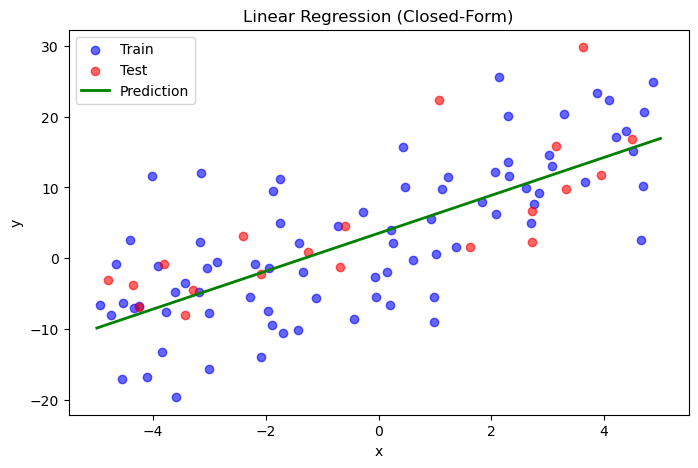

In [175]:
class LinearRegressionClosedForm:
    """Linear Regression via the Normal Equation."""
    def __init__(self):
        self.w = None
    def fit(self, X, y):
        Xb = add_bias_column(X)
        self.w = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
        return self
    def predict(self, X):
        Xb = add_bias_column(X)
        return Xb @ self.w

# Demo
X_reg, y_reg = make_regression_data(n=100, noise=8, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, 0.2, seed=42)

lr_cf = LinearRegressionClosedForm()
lr_cf.fit(X_train, y_train)

print(f'Learned weights: w0={lr_cf.w[0]:.4f}, w1={lr_cf.w[1]:.4f}')
print(f'(True: w0=4, w1=3)')
print(f'Train MSE: {mean_squared_error(y_train, lr_cf.predict(X_train)):.4f}')
print(f'Test  MSE: {mean_squared_error(y_test, lr_cf.predict(X_test)):.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train, y_train, c='blue', label='Train', alpha=0.6)
ax.scatter(X_test, y_test, c='red', label='Test', alpha=0.6)
x_line = np.linspace(-5, 5, 100).reshape(-1, 1)
ax.plot(x_line, lr_cf.predict(x_line), 'g-', linewidth=2, label='Prediction')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Linear Regression (Closed-Form)')
ax.legend()
plt.show()

### 2.4 Gradient Descent for Linear Regression

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \cdot \nabla_\mathbf{w} J, \quad \nabla_\mathbf{w} J = -\frac{2}{n}\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w})$$

#### Intuition

Gradient descent is like **rolling a ball down a hill**. The gradient $\nabla J$ points in the direction of steepest *ascent* (uphill). By subtracting it, we move *downhill* toward the minimum.

- **Learning rate $\eta$**: Controls step size. Too small → painfully slow convergence. Too large → overshoot and diverge (the ball bounces out of the bowl).
- **The $\frac{1}{n}$ factor**: Averages the gradient across all samples, so the step size doesn't grow with dataset size.

**The gradient in words:** For each weight $w_j$, the gradient tells us: "If $w_j$ increases, how much does the error change?" The update then nudges $w_j$ in the direction that *decreases* the error.

**Batch GD vs. SGD:** Batch GD uses the entire dataset each step (smooth but slow). SGD uses one random sample (noisy but fast, and the noise helps escape saddle points). Mini-batch SGD is the sweet spot used everywhere in deep learning.

**Convergence guarantee:** For convex problems with a properly chosen learning rate, gradient descent is *guaranteed* to converge to the global minimum. For non-convex problems (like neural networks), no such guarantee exists — but it works remarkably well in practice.

Weights (GD):  w0=3.5379, w1=2.6789
Weights (CF):  w0=3.5379, w1=2.6789
Train MSE: 54.2514


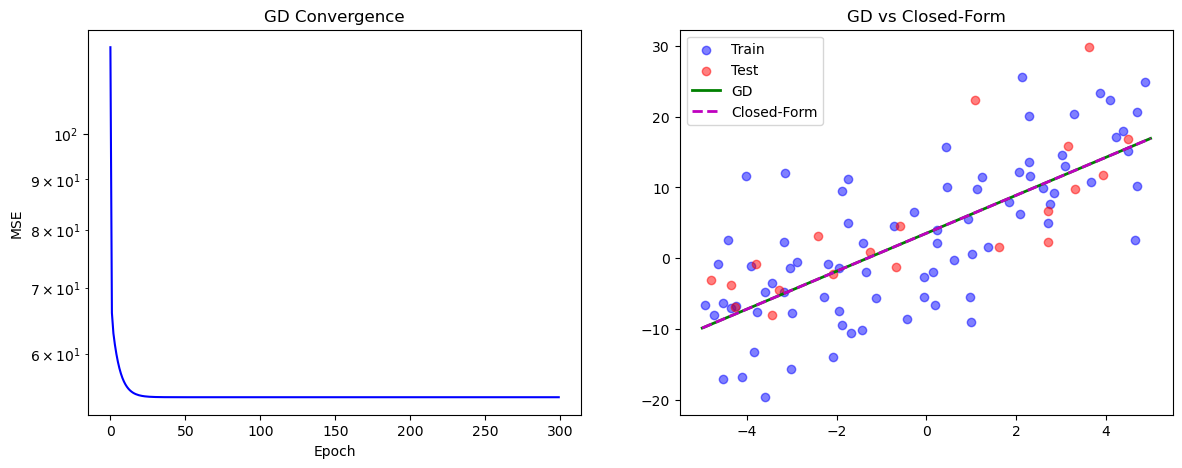

In [176]:
class LinearRegressionGD:
    """Linear Regression via Batch Gradient Descent."""
    def __init__(self, learning_rate=0.01, n_epochs=200):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None
        self.cost_history = []
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            y_pred = Xb @ self.w
            gradient = -2 * Xb.T @ (y - y_pred) / n
            self.w = self.w - self.lr * gradient
            self.cost_history.append(np.mean((y - y_pred) ** 2))
        return self
    def predict(self, X):
        return add_bias_column(X) @ self.w

lr_gd = LinearRegressionGD(learning_rate=0.05, n_epochs=300)
lr_gd.fit(X_train, y_train)

print(f'Weights (GD):  w0={lr_gd.w[0]:.4f}, w1={lr_gd.w[1]:.4f}')
print(f'Weights (CF):  w0={lr_cf.w[0]:.4f}, w1={lr_cf.w[1]:.4f}')
print(f'Train MSE: {mean_squared_error(y_train, lr_gd.predict(X_train)):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lr_gd.cost_history, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title('GD Convergence'); axes[0].set_yscale('log')
axes[1].scatter(X_train, y_train, c='blue', label='Train', alpha=0.5)
axes[1].scatter(X_test, y_test, c='red', label='Test', alpha=0.5)
x_line = np.linspace(-5, 5, 100).reshape(-1, 1)
axes[1].plot(x_line, lr_gd.predict(x_line), 'g-', linewidth=2, label='GD')
axes[1].plot(x_line, lr_cf.predict(x_line), 'm--', linewidth=2, label='Closed-Form')
axes[1].legend(); axes[1].set_title('GD vs Closed-Form')
plt.show()

/Users/armin/Library/mljar-studio/jlab_server/lib/python3.11/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/d6/99xlq68949b33wczjn2z4c2w0000gn/T/ipykernel_73944/2258592474.py:16: RuntimeWarning: overflow encountered in square
  self.cost_history.append(np.mean((y - y_pred) ** 2))
/Users/armin/Library/mljar-studio/jlab_server/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


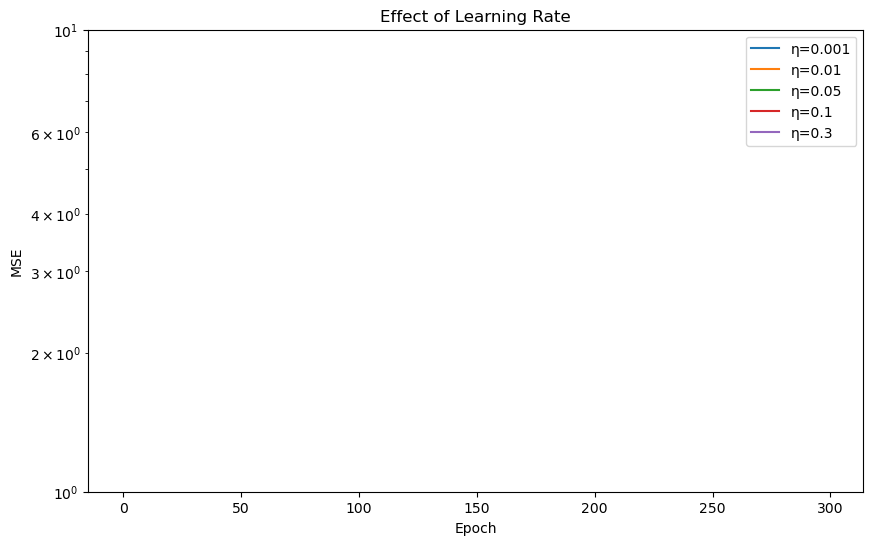

In [177]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
fig, ax = plt.subplots(figsize=(10, 6))
for lr_val in learning_rates:
    m = LinearRegressionGD(learning_rate=lr_val, n_epochs=300)
    m.fit(X_train, y_train)
    ax.plot(m.cost_history, label=f'η={lr_val}')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Effect of Learning Rate'); ax.set_yscale('log')
ax.legend()
plt.show()

### 2.6 Stochastic Gradient Descent (SGD)

Update weights using **one random sample** at a time instead of the full batch.

#### Deep Understanding

SGD is the workhorse of modern machine learning. Here is why it matters:

1. **Speed:** Each update costs $O(d)$ instead of $O(nd)$. For millions of samples, this is the difference between minutes and days.
2. **Memory:** Only one sample needs to be in memory at a time.
3. **Noise as a feature:** The stochastic nature of SGD means each update is a noisy estimate of the true gradient. This noise is actually *beneficial* — it helps the optimizer escape saddle points and shallow local minima.
4. **Online learning:** SGD can update the model as new data arrives, without retraining on the full dataset.

**The trade-off:** SGD's noisy trajectory means it never fully settles at the minimum — it bounces around in a neighborhood. This is typically resolved by **decaying the learning rate** over time, so the steps get smaller and smaller as we approach the minimum.

**Mini-batch SGD** (the practical sweet spot): Use a small batch of 16–256 samples. This gives a less noisy gradient estimate than pure SGD, while still being much faster than full-batch GD. This is what virtually all deep learning frameworks use.

Weights (SGD): w0=3.3958, w1=3.1951
Train MSE: 56.6052


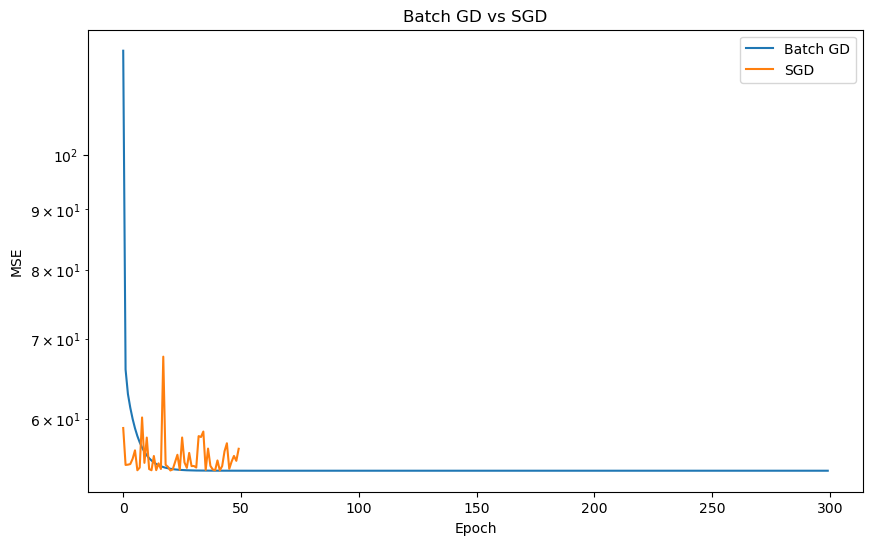

In [178]:
class LinearRegressionSGD:
    """Linear Regression via Stochastic Gradient Descent."""
    def __init__(self, learning_rate=0.01, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None
        self.cost_history = []
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            perm = np.random.permutation(n)
            for i in perm:
                xi = Xb[i]; yi = y[i]
                err = yi - self.w @ xi
                self.w = self.w + self.lr * err * xi
            self.cost_history.append(np.mean((y - Xb @ self.w) ** 2))
        return self
    def predict(self, X):
        return add_bias_column(X) @ self.w

lr_sgd = LinearRegressionSGD(learning_rate=0.01, n_epochs=50)
lr_sgd.fit(X_train, y_train)
print(f'Weights (SGD): w0={lr_sgd.w[0]:.4f}, w1={lr_sgd.w[1]:.4f}')
print(f'Train MSE: {mean_squared_error(y_train, lr_sgd.predict(X_train)):.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lr_gd.cost_history, label='Batch GD')
ax.plot(lr_sgd.cost_history, label='SGD')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Batch GD vs SGD'); ax.set_yscale('log')
ax.legend()
plt.show()

---

## 3. Logistic Regression

### 3.1 Sigmoid & Cross-Entropy Loss

$$h_\mathbf{w}(\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x}) = \frac{1}{1 + \exp(-\mathbf{w}^T \mathbf{x})}$$

$$J(\mathbf{w}) = -\sum_{i=1}^{n} \left[ y^{(i)} \log h(\mathbf{x}^{(i)}) + (1 - y^{(i)}) \log(1 - h(\mathbf{x}^{(i)})) \right]$$

**Gradient:** $\nabla_\mathbf{w} J = \frac{1}{n}\mathbf{X}^T (h - \mathbf{y})$

#### Intuition: From Regression to Classification

Linear regression predicts a continuous value. But what if we want to predict a **binary label** (0 or 1)? We need to:

1. **Squash** the linear output $\mathbf{w}^T\mathbf{x}$ into $[0, 1]$ → the **sigmoid function** $\sigma$.
2. **Interpret** the output as a probability: $h(\mathbf{x}) = P(y=1 | \mathbf{x})$.
3. **Classify**: predict 1 if $h(\mathbf{x}) \geq 0.5$, else 0.

**Why sigmoid?** The sigmoid naturally arises from the **maximum likelihood principle**. If we assume $P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x})$, then maximizing the likelihood of observing our data leads exactly to minimizing the **cross-entropy loss**.

**Why cross-entropy, not MSE?** Using MSE with sigmoid leads to a non-convex loss with a terrible gradient: when the prediction is very wrong, the gradient becomes tiny (the sigmoid saturates), so learning stalls. Cross-entropy cancels the sigmoid derivative: $\nabla J = \frac{1}{n}\mathbf{X}^T(h - \mathbf{y})$. The gradient is proportional to the **error** $(h - \mathbf{y})$ — the more wrong you are, the harder you get pushed. This is the same gradient form as linear regression! The magic of cross-entropy is that it makes logistic regression behave like linear regression in terms of gradient flow.

**The decision boundary** is a hyperplane $\mathbf{w}^T\mathbf{x} = 0$ (where $\sigma = 0.5$). Logistic regression is fundamentally a **linear classifier** — it can only draw straight lines (or hyperplanes).

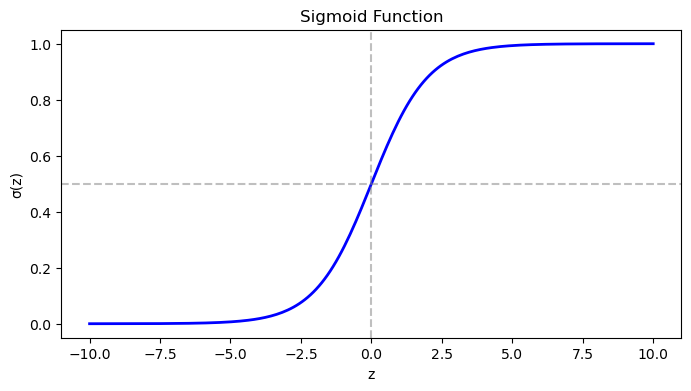

In [179]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

z = np.linspace(-10, 10, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, sigmoid(z), 'b-', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('z'); ax.set_ylabel('σ(z)')
ax.set_title('Sigmoid Function')
plt.show()

Train Acc: 1.0000
Test  Acc: 1.0000


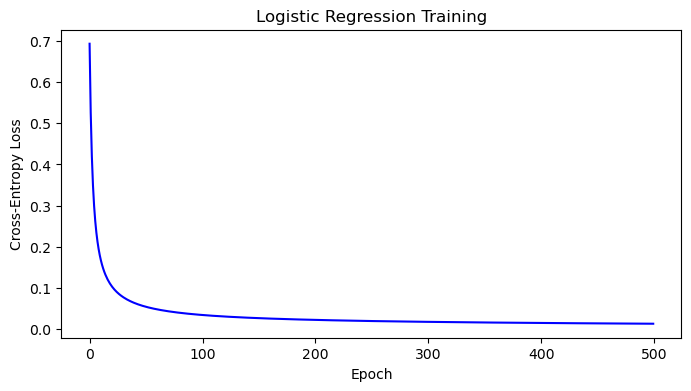

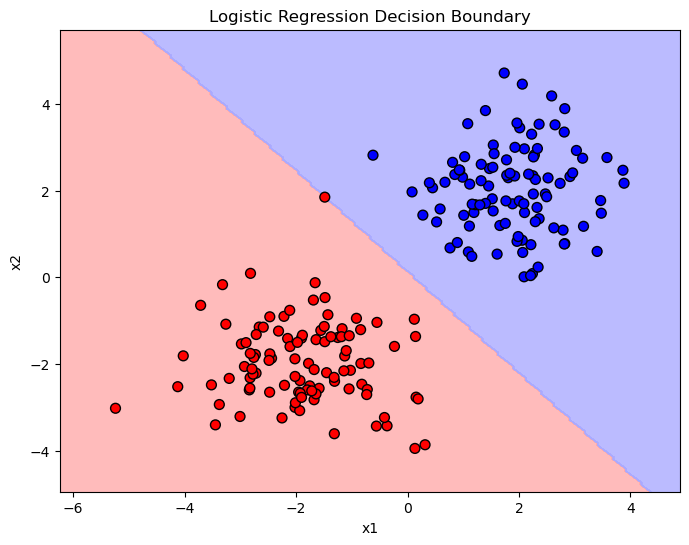

In [180]:
class LogisticRegression:
    """Binary Logistic Regression trained with Gradient Descent."""
    def __init__(self, learning_rate=0.1, n_epochs=500, l2_lambda=0.0):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.l2_lambda = l2_lambda
        self.w = None
        self.cost_history = []
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            h = sigmoid(Xb @ self.w)
            gradient = Xb.T @ (h - y) / n
            if self.l2_lambda > 0:
                reg = (self.l2_lambda / n) * self.w
                reg[0] = 0
                gradient += reg
            self.w -= self.lr * gradient
            eps = 1e-12
            cost = -np.mean(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
            self.cost_history.append(cost)
        return self
    def predict_proba(self, X):
        return sigmoid(add_bias_column(X) @ self.w)
    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

X_clf, y_clf = make_classification_data(n=200, d=2, seed=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, 0.2, seed=42)

log_reg = LogisticRegression(learning_rate=0.1, n_epochs=500)
log_reg.fit(X_clf_train, y_clf_train)

print(f'Train Acc: {accuracy(y_clf_train, log_reg.predict(X_clf_train)):.4f}')
print(f'Test  Acc: {accuracy(y_clf_test, log_reg.predict(X_clf_test)):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(log_reg.cost_history, 'b-')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Logistic Regression Training')
plt.show()

plot_decision_boundary(X_clf, y_clf, log_reg, title='Logistic Regression Decision Boundary')

### 3.2 Multi-class Logistic Regression (Softmax)

$$P(y=k|\mathbf{x}) = \frac{\exp(\mathbf{w}_k^T \mathbf{x})}{\sum_j \exp(\mathbf{w}_j^T \mathbf{x})}$$

$$\frac{\exp(r_i - \max{r_l})}{\sum_j \exp(r_j - \max{r_l})}$$

$$l(f(x), y_{true})=-\log(P(y=y_{true}|\mathbf{x}))$$

#### Intuition: From Binary to Multi-class

When there are more than two classes, the sigmoid generalizes to the **softmax function**. Instead of one weight vector, we have one weight vector **per class** ($\mathbf{w}_k$ for class $k$).

**The softmax "competition":** Each class produces a raw score (logit) $r_k = \mathbf{w}_k^T \mathbf{x}$. Softmax converts these scores to probabilities by:
- Exponentiating each score (making everything positive).
- Normalizing so they sum to 1.

The key insight is that softmax creates **competition** between classes: increasing the score for one class *decreases* the probability of all other classes, because they must sum to 1.

**Numerical stability trick:** The raw exponentials can overflow (e.g., $e^{1000}$). The fix is elegant: subtract the maximum logit before exponentiating. Since $\frac{e^{r_k}}{\sum_j e^{r_j}} = \frac{e^{r_k - c}}{\sum_j e^{r_j - c}}$ for any constant $c$, choosing $c = \max_j r_j$ keeps all exponents $\leq 0$, preventing overflow.

**Cross-entropy loss for multi-class:** $-\log P(y_{true}|\mathbf{x})$. This is the negative log-likelihood — we want to maximize the probability assigned to the true class. The gradient has the same beautiful form: $\nabla_{\mathbf{w}_k} J = \frac{1}{n}\mathbf{X}^T(p_k - y_k)$, where $p_k$ is the predicted probability and $y_k$ is the one-hot label. Again, the gradient is proportional to the **prediction error**.

In [181]:
def one_hot(y, K):
    Y = np.zeros((len(y), K)) # n * k
    Y[np.arange(len(y)), y] = 1
    return Y

In [182]:
def loss_function(W, X, y):
    logits = X @ W.T
    logits = logits - reduce(logits, 'n k -> n', 'max')[:, None] # n * k
    print(np.max(logits))
    exp_all = np.exp(X @ W.T) # n * k, score for each sample and each class
    print(exp_all.shape)
    denominator = rearrange(reduce(exp_all, 'n k -> n', 'sum'), 'n -> n 1') # n * 1
    print(denominator.shape)
    softmax_all = exp_all / denominator # n * k
    print(softmax_all.shape)
    return reduce(-np.log(softmax_all) * one_hot(y, 3), 'n k -> n', 'sum').mean() 

Accuracy: 1.0000


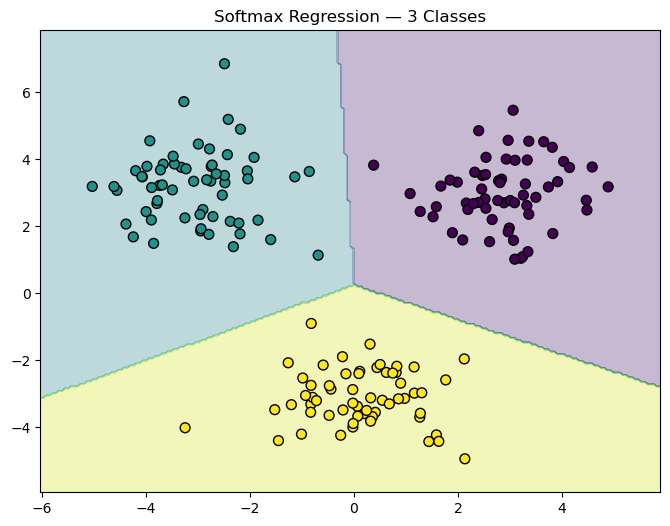

In [183]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)



class SoftmaxRegression:
    def __init__(self, learning_rate=0.5, n_epochs=300):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.W = None
        self.cost_history = []
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        K = len(np.unique(y))
        Y = one_hot(y, K)
        self.W = np.zeros((d, K))
        for epoch in range(self.n_epochs):
            probs = softmax(Xb @ self.W)
            gradient = Xb.T @ (probs - Y) / n
            self.W -= self.lr * gradient
            eps = 1e-12
            cost = -np.mean(np.sum(Y * np.log(probs + eps), axis=1))
            self.cost_history.append(cost)
        return self
    def predict(self, X):
        return np.argmax(add_bias_column(X) @ self.W, axis=1)

# 3-class demo
rng = np.random.RandomState(42)
npc = 60
X_multi = np.vstack([rng.randn(npc, 2)+[3,3], rng.randn(npc, 2)+[-3,3], rng.randn(npc, 2)+[0,-3]])
y_multi = np.array([0]*npc + [1]*npc + [2]*npc)
perm = rng.permutation(len(y_multi))
X_multi, y_multi = X_multi[perm], y_multi[perm]

sm = SoftmaxRegression(learning_rate=0.5, n_epochs=300)
sm.fit(X_multi, y_multi)
print(f'Accuracy: {accuracy(y_multi, sm.predict(X_multi)):.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
xm, xM = X_multi[:,0].min()-1, X_multi[:,0].max()+1
ym, yM = X_multi[:,1].min()-1, X_multi[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(xm, xM, 200), np.linspace(ym, yM, 200))
Z = sm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
ax.scatter(X_multi[:,0], X_multi[:,1], c=y_multi, cmap='viridis', edgecolors='k', s=50)
ax.set_title('Softmax Regression — 3 Classes')
plt.show()

In [184]:
# ------------------------------------------------------------
# Datasets used by Decision Trees, Ensembles, and later sections
# ------------------------------------------------------------

# Moons dataset (non-linear binary classification)
X_moons, y_moons = make_moons(n=300, noise=0.2, seed=42)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_moons, y_moons, 0.2, seed=42)
X_m_tr_s, X_m_te_s, _, _ = standardize(X_m_tr, X_m_te)

# Sin(x) regression dataset (non-linear regression)
rng_nl = np.random.RandomState(42)
n_nl = 200
X_nl = rng_nl.uniform(-5, 5, (n_nl, 1))
y_nl = np.sin(X_nl[:, 0]) + 0.1 * rng_nl.randn(n_nl)
X_nl_tr, X_nl_te, y_nl_tr, y_nl_te = train_test_split(X_nl, y_nl, 0.2, seed=42)
X_nl_tr_s, X_nl_te_s, _, _ = standardize(X_nl_tr, X_nl_te)

# Classification data for logistic regression demos
X_clf, y_clf = make_classification_data(n=200, d=2, seed=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf, y_clf, 0.2, seed=42)

# {-1, +1} labels for AdaBoost / Gradient Boosting / Perceptron
y_ab_tr = np.where(y_m_tr == 0, -1, 1)
y_ab_te = np.where(y_m_te == 0, -1, 1)

print('Datasets ready: moons, sin(x), classification')

Datasets ready: moons, sin(x), classification


---

## 4. Decision Trees

### 4.1 Decision Tree Classifier

**Gini Impurity:** $1 - \sum_k p_k^2$ 

$0.3,0.2,0.5$

**Entropy:** $-\sum_k p_k \log_2 p_k$

#### Intuition: 20 Questions for Data

A decision tree works like the game of **20 Questions**: it asks a series of yes/no questions about the features, narrowing down the prediction step by step.

**How a tree is built (recursive splitting):**
1. Start with all data at the root.
2. Find the **best split**: which feature, at what threshold, best separates the classes?
3. Split the data into two groups based on that threshold.
4. **Recurse** on each group until a stopping condition is met (max depth, pure node, too few samples).

**Impurity measures** quantify how "mixed" a node is:
- **Gini Impurity**: $1 - \sum p_k^2$. If a node is pure (all one class), Gini = 0. If classes are evenly mixed, Gini is maximized.
- **Entropy**: $-\sum p_k \log_2 p_k$. Same intuition — 0 for pure nodes, maximized for mixed.

**Information Gain** = parent impurity − weighted average child impurity. We choose the split that maximizes information gain — the split that most reduces "mixedness."

**Why trees are great:** No assumptions about data distribution, handle mixed feature types, interpretable (you can trace the decision path), and naturally capture feature interactions.

**Why trees are terrible alone:** High variance — small changes in data can produce completely different trees. This is exactly the problem that **ensemble methods** (bagging, random forests, boosting) solve.

Train Acc: 0.9917
Test  Acc: 0.9333


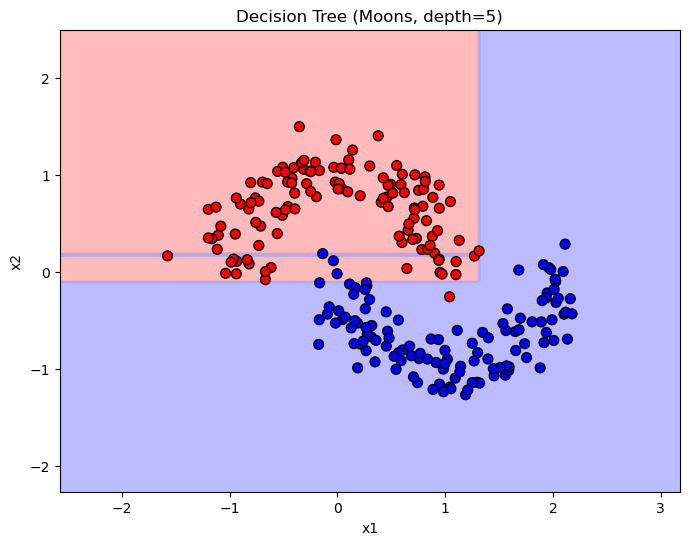

In [185]:
class DecisionTreeClassifier:
    """Decision Tree for Classification (from scratch)."""
    def __init__(self, max_depth=5, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.tree = None

    def _gini(self, y):
        _, c = np.unique(y, return_counts=True)
        return 1 - np.sum((c / len(y)) ** 2)

    def _entropy(self, y):
        _, c = np.unique(y, return_counts=True)
        p = c / len(y)
        return -np.sum(p * np.log2(p + 1e-12))

    def _impurity(self, y):
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    def _best_split(self, X, y):
        n, d = X.shape
        best_gain = -float('inf')
        best_feat, best_thr = None, None
        parent_imp = self._impurity(y)
        for feat in range(d):
            for thr in np.unique(X[:, feat]):
                lm = X[:, feat] <= thr
                rm = ~lm
                nl, nr = lm.sum(), rm.sum()
                if nl == 0 or nr == 0: continue
                ci = (nl/n)*self._impurity(y[lm]) + (nr/n)*self._impurity(y[rm])
                gain = parent_imp - ci
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr
        return best_feat, best_thr, best_gain

    def _build(self, X, y, depth=0):
        n = len(y)
        if depth >= self.max_depth or n < self.min_samples_split or len(np.unique(y)) == 1:
            cls, cnt = np.unique(y, return_counts=True)
            return {'type': 'leaf', 'pred': cls[np.argmax(cnt)]}
        feat, thr, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            cls, cnt = np.unique(y, return_counts=True)
            return {'type': 'leaf', 'pred': cls[np.argmax(cnt)]}
        lm = X[:, feat] <= thr
        return {'type': 'node', 'feat': feat, 'thr': thr,
                'left': self._build(X[lm], y[lm], depth+1),
                'right': self._build(X[~lm], y[~lm], depth+1)}

    def fit(self, X, y):
        self.tree = self._build(X, y)
        return self

    def _predict_one(self, x, node):
        if node['type'] == 'leaf': return node['pred']
        if x[node['feat']] <= node['thr']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

# Demo
dt = DecisionTreeClassifier(max_depth=5, criterion='gini')
dt.fit(X_m_tr, y_m_tr)
print(f'Train Acc: {accuracy(y_m_tr, dt.predict(X_m_tr)):.4f}')
print(f'Test  Acc: {accuracy(y_m_te, dt.predict(X_m_te)):.4f}')
plot_decision_boundary(X_m_tr, y_m_tr, dt, title='Decision Tree (Moons, depth=5)')

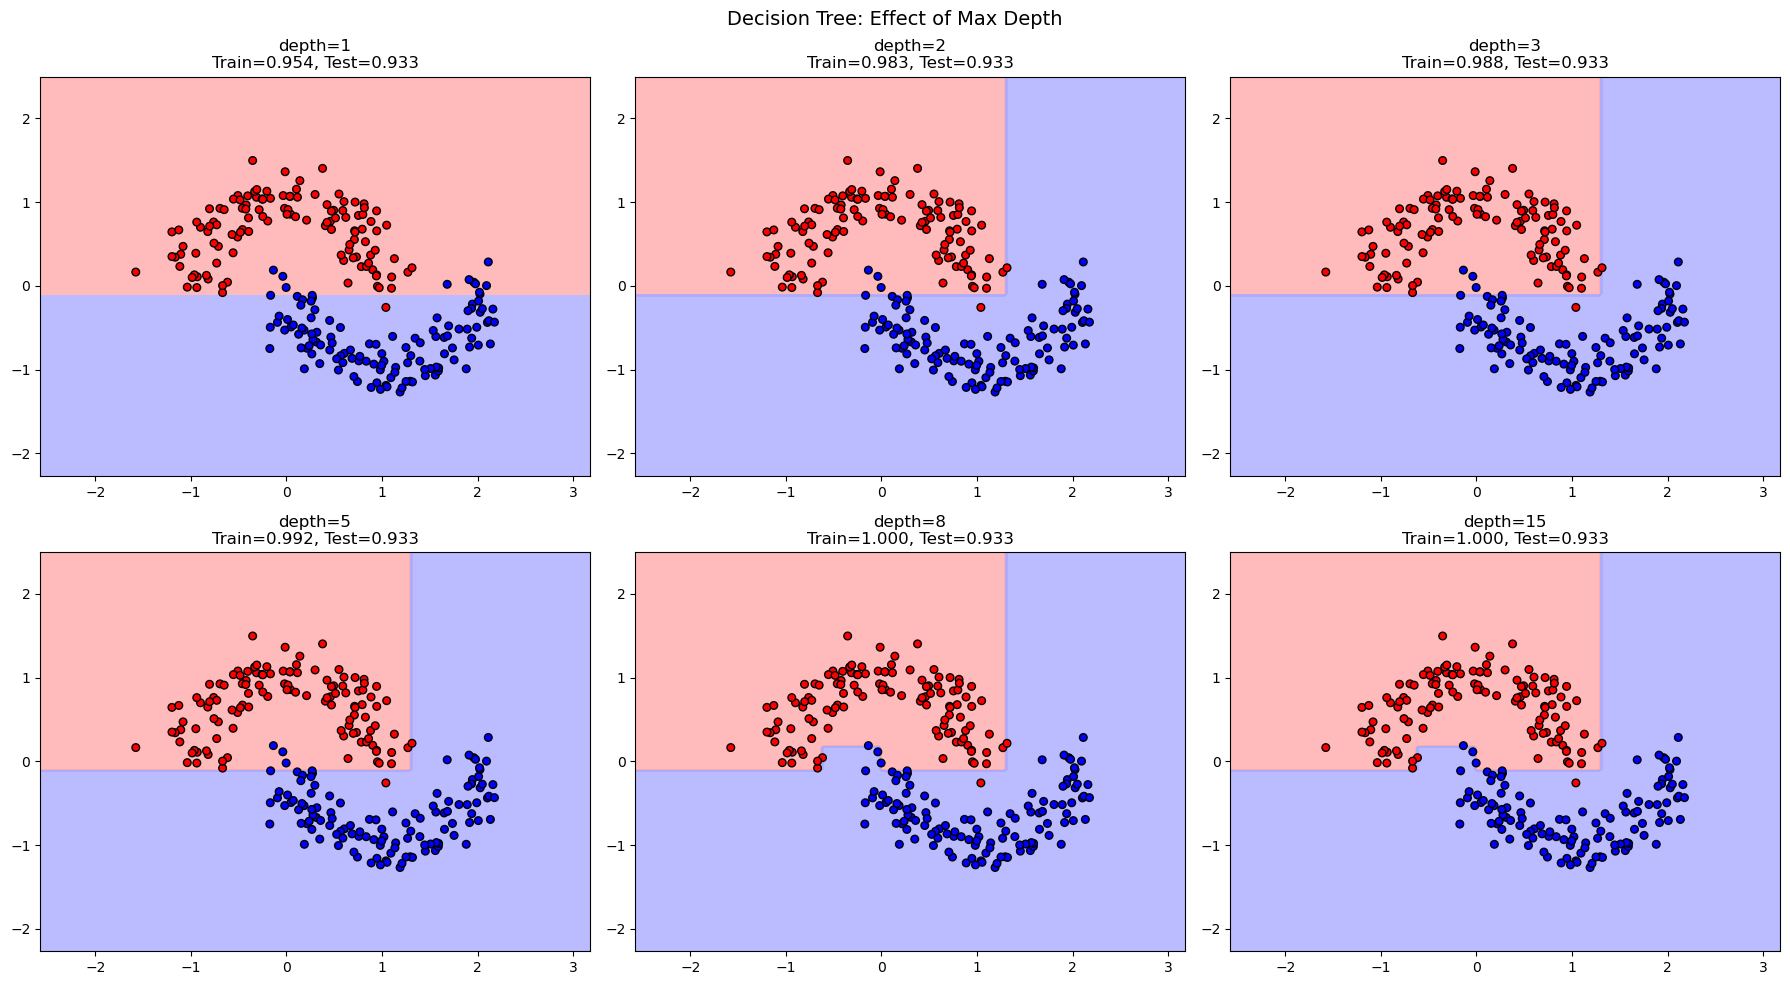

In [186]:
# Effect of tree depth
depths = [1, 2, 3, 5, 8, 15]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, depth in enumerate(depths):
    ax = axes[idx // 3][idx % 3]
    dt_d = DecisionTreeClassifier(max_depth=depth)
    dt_d.fit(X_m_tr, y_m_tr)
    tr = accuracy(y_m_tr, dt_d.predict(X_m_tr))
    te = accuracy(y_m_te, dt_d.predict(X_m_te))
    xm, xM = X_m_tr[:,0].min()-1, X_m_tr[:,0].max()+1
    ym, yM = X_m_tr[:,1].min()-1, X_m_tr[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(xm, xM, 150), np.linspace(ym, yM, 150))
    Z = dt_d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.8)
    ax.scatter(X_m_tr[:,0], X_m_tr[:,1], c=y_m_tr,
               cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k', s=30)
    ax.set_title(f'depth={depth}\nTrain={tr:.3f}, Test={te:.3f}')
plt.suptitle('Decision Tree: Effect of Max Depth', fontsize=14)
plt.tight_layout(); plt.show()

### 4.2 Decision Tree Regressor

#### Intuition

For regression, the tree uses **variance reduction** instead of impurity reduction. Each leaf predicts the **mean** of the training samples that reach it. The best split is the one that most reduces the weighted variance of the two children.

The result is a **piecewise constant** function — the prediction is a flat line within each leaf region. Deeper trees produce more pieces, fitting more complex functions but risking overfitting.

Train MSE: 0.0522
Test  MSE: 0.0519


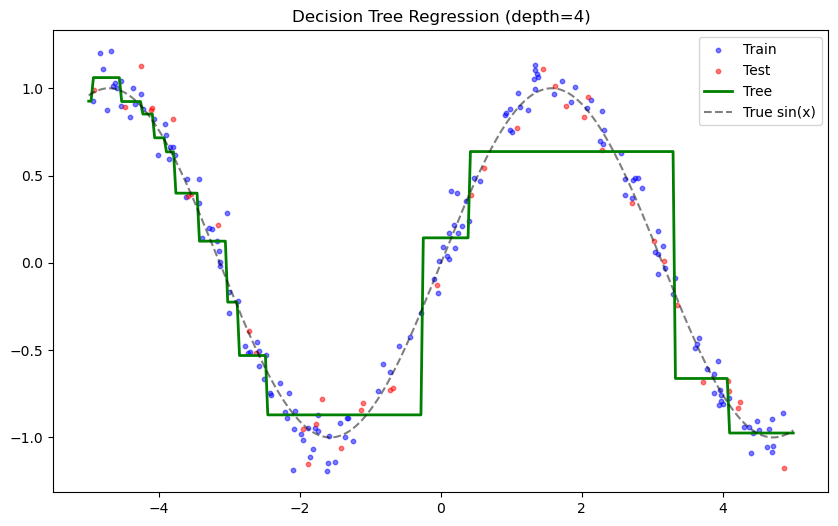

In [187]:
class DecisionTreeRegressor:
    """Decision Tree for Regression (from scratch)."""
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _best_split(self, X, y):
        n, d = X.shape
        best_gain = -float('inf')
        best_feat, best_thr = None, None
        parent_var = np.var(y) if len(y) > 0 else 0
        for feat in range(d):
            for thr in np.unique(X[:, feat]):
                lm = X[:, feat] <= thr
                rm = ~lm
                nl, nr = lm.sum(), rm.sum()
                if nl == 0 or nr == 0: continue
                cv = (nl/n)*np.var(y[lm]) + (nr/n)*np.var(y[rm])
                gain = parent_var - cv
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr
        return best_feat, best_thr, best_gain

    def _build(self, X, y, depth=0):
        n = len(y)
        if depth >= self.max_depth or n < self.min_samples_split or len(y) <= 1:
            return {'type': 'leaf', 'pred': np.mean(y) if len(y) > 0 else 0}
        feat, thr, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            return {'type': 'leaf', 'pred': np.mean(y)}
        lm = X[:, feat] <= thr
        return {'type': 'node', 'feat': feat, 'thr': thr,
                'left': self._build(X[lm], y[lm], depth+1),
                'right': self._build(X[~lm], y[~lm], depth+1)}

    def fit(self, X, y):
        self.tree = self._build(X, y)
        return self

    def _predict_one(self, x, node):
        if node['type'] == 'leaf': return node['pred']
        if x[node['feat']] <= node['thr']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

# Demo: fit sin(x)
dt_reg = DecisionTreeRegressor(max_depth=4)
dt_reg.fit(X_nl_tr, y_nl_tr)
print(f'Train MSE: {mean_squared_error(y_nl_tr, dt_reg.predict(X_nl_tr)):.4f}')
print(f'Test  MSE: {mean_squared_error(y_nl_te, dt_reg.predict(X_nl_te)):.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_nl_tr, y_nl_tr, c='blue', s=10, alpha=0.5, label='Train')
ax.scatter(X_nl_te, y_nl_te, c='red', s=10, alpha=0.5, label='Test')
x_curve = np.linspace(-5, 5, 300).reshape(-1, 1)
ax.plot(x_curve, dt_reg.predict(x_curve), 'g-', linewidth=2, label='Tree')
ax.plot(x_curve, np.sin(x_curve), 'k--', alpha=0.5, label='True sin(x)')
ax.set_title('Decision Tree Regression (depth=4)')
ax.legend()
plt.show()

---

## 5. Ensemble Methods

### 5.1 Bagging (Bootstrap Aggregating)

Train $B$ models on bootstrap samples; aggregate by majority vote. Reduces **variance**.

#### Intuition: Wisdom of the Crowd

The fundamental idea behind all ensemble methods is:

> **A group of weak learners, combined properly, can form a strong learner.**

Think of it like asking many people for an answer and averaging — if their errors are independent, they tend to cancel out.

**Bagging** (Bootstrap Aggregating) works as follows:
1. **Bootstrap:** Create $B$ different datasets by sampling *with replacement* from the original training set. Each bootstrap sample has the same size as the original, but some samples appear multiple times and some don't appear at all (on average, 37% of samples are left out — these are called "out-of-bag" samples).
2. **Train:** Fit a separate model (typically a deep decision tree) on each bootstrap sample.
3. **Aggregate:** For classification, take a majority vote. For regression, take the average.

**Why does it work?** Deep decision trees have **low bias but high variance**. By averaging $B$ trees trained on different data samples, the variance is reduced by a factor of $B$ (assuming independence). The bias stays the same. Since the trees are deep (low bias), the ensemble has both low bias *and* low variance.

**The math:** If individual models have variance $\sigma^2$ and correlation $\rho$, the ensemble variance is:

$$\text{Var}_{\text{ensemble}} = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, the second term vanishes, but the first term (due to correlation) remains. This is why **decorrelating** the trees (as in Random Forest) is important.

Bagging - Train Acc: 0.9875
Bagging - Test  Acc: 0.9333
Single Tree - Train Acc: 0.9917
Single Tree - Test  Acc: 0.9333


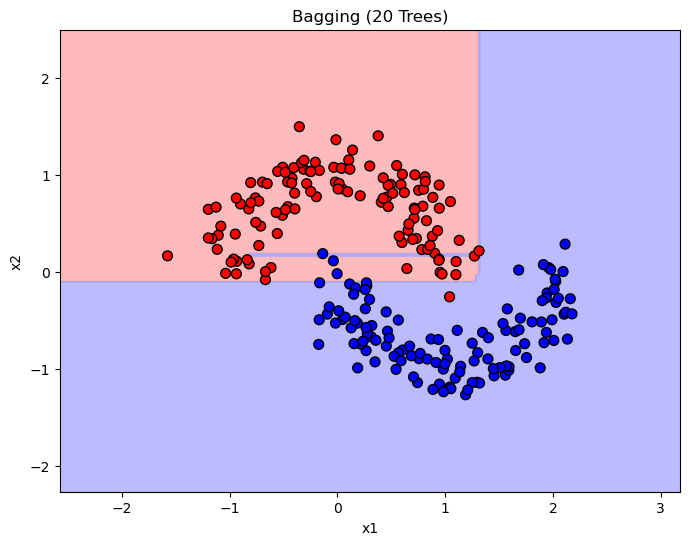

In [188]:
class BaggingClassifier:
    """Bootstrap Aggregating with Decision Trees."""
    def __init__(self, n_estimators=20, max_depth=5, seed=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.rng = np.random.RandomState(seed)
        self.trees = []

    def fit(self, X, y):
        n = len(y)
        self.trees = []
        for _ in range(self.n_estimators):
            idx = self.rng.choice(n, size=n, replace=True)
            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees])
        return np.array([Counter(preds[:, i]).most_common(1)[0][0] for i in range(preds.shape[1])])

bagging = BaggingClassifier(n_estimators=20, max_depth=5, seed=42)
bagging.fit(X_m_tr, y_m_tr)
print(f'Bagging - Train Acc: {accuracy(y_m_tr, bagging.predict(X_m_tr)):.4f}')
print(f'Bagging - Test  Acc: {accuracy(y_m_te, bagging.predict(X_m_te)):.4f}')

single = DecisionTreeClassifier(max_depth=5)
single.fit(X_m_tr, y_m_tr)
print(f'Single Tree - Train Acc: {accuracy(y_m_tr, single.predict(X_m_tr)):.4f}')
print(f'Single Tree - Test  Acc: {accuracy(y_m_te, single.predict(X_m_te)):.4f}')

plot_decision_boundary(X_m_tr, y_m_tr, bagging, title='Bagging (20 Trees)')

### 5.2 Random Forest

Like bagging, but at each split only consider a **random subset of features**. This decorrelates trees.

#### Intuition: The Power of Randomness

Random Forest improves on bagging by addressing the **correlation problem**. In bagging, if one feature is very strong, every tree will split on it first, making all trees similar (correlated). Correlated trees don't benefit much from averaging.

**The fix:** At *each split*, only consider a **random subset** of features (typically $\sqrt{d}$ for classification). This forces trees to explore different features and make different split choices, producing **decorrelated** trees.

**Why this matters:** Remember the ensemble variance formula:
$$\text{Var}_{\text{ensemble}} = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Random Forest reduces $\rho$ (correlation between trees), which reduces the first term that bagging alone can't address.

**Key properties:**
- **Robust to overfitting:** Each tree overfits, but in different ways. Averaging cancels the overfitting.
- **Feature importance:** By measuring how much each feature reduces impurity across all trees, we get a natural feature importance ranking.
- **Few hyperparameters:** Mainly the number of trees and max depth. Very little tuning needed.
- **Works out of the box:** One of the best "off-the-shelf" classifiers — often hard to beat without significant tuning.

Random Forest - Train Acc: 0.9917
Random Forest - Test  Acc: 0.9333


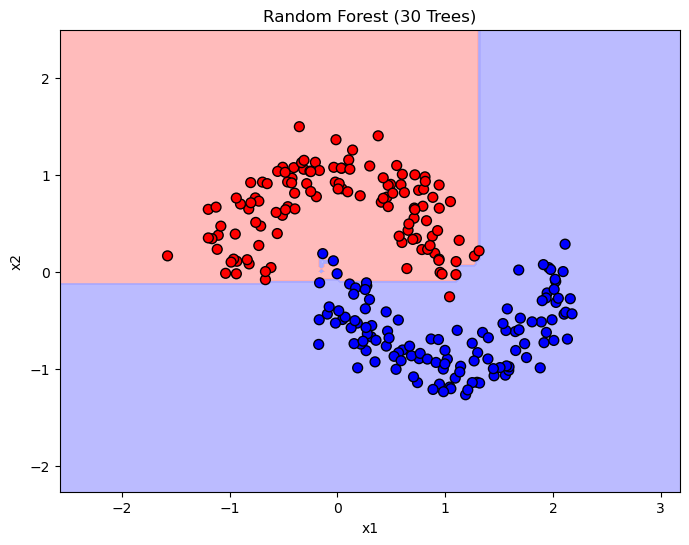

In [189]:
class RandomForestClassifierScratch:
    """Random Forest from scratch."""
    def __init__(self, n_estimators=30, max_depth=5, max_features=None, seed=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.rng = np.random.RandomState(seed)
        self.trees = []

    def fit(self, X, y):
        n, d = X.shape
        if self.max_features is None:
            self.max_features = max(1, int(np.sqrt(d)))
        self.trees = []
        for _ in range(self.n_estimators):
            idx = self.rng.choice(n, size=n, replace=True)
            tree = self._build(X[idx], y[idx], 0)
            self.trees.append(tree)
        return self

    def _gini(self, y):
        if len(y) == 0: return 0
        _, c = np.unique(y, return_counts=True)
        return 1 - np.sum((c / len(y)) ** 2)

    def _build(self, X, y, depth):
        n, d = X.shape
        if depth >= self.max_depth or len(np.unique(y)) == 1 or n < 2:
            cls, cnt = np.unique(y, return_counts=True)
            return {'type': 'leaf', 'pred': cls[np.argmax(cnt)] if len(cls) > 0 else 0}
        feat_subset = self.rng.choice(d, size=min(self.max_features, d), replace=False)
        best_gain = -float('inf')
        best_feat, best_thr = None, None
        parent_gini = self._gini(y)
        for feat in feat_subset:
            for thr in np.unique(X[:, feat]):
                lm = X[:, feat] <= thr
                rm = ~lm
                nl, nr = lm.sum(), rm.sum()
                if nl == 0 or nr == 0: continue
                cg = (nl/n)*self._gini(y[lm]) + (nr/n)*self._gini(y[rm])
                gain = parent_gini - cg
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr
        if best_feat is None or best_gain <= 0:
            cls, cnt = np.unique(y, return_counts=True)
            return {'type': 'leaf', 'pred': cls[np.argmax(cnt)] if len(cls) > 0 else 0}
        lm = X[:, best_feat] <= best_thr
        return {'type': 'node', 'feat': best_feat, 'thr': best_thr,
                'left': self._build(X[lm], y[lm], depth+1),
                'right': self._build(X[~lm], y[~lm], depth+1)}

    def _predict_one(self, x, node):
        if node['type'] == 'leaf': return node['pred']
        if x[node['feat']] <= node['thr']:
            return self._predict_one(x, node['left'])
        return self._predict_one(x, node['right'])

    def predict(self, X):
        preds = np.array([[self._predict_one(x, t) for t in self.trees] for x in X])
        return np.array([Counter(preds[i]).most_common(1)[0][0] for i in range(len(X))])

rf = RandomForestClassifierScratch(n_estimators=30, max_depth=5, seed=42)
rf.fit(X_m_tr, y_m_tr)
print(f'Random Forest - Train Acc: {accuracy(y_m_tr, rf.predict(X_m_tr)):.4f}')
print(f'Random Forest - Test  Acc: {accuracy(y_m_te, rf.predict(X_m_te)):.4f}')
plot_decision_boundary(X_m_tr, y_m_tr, rf, title='Random Forest (30 Trees)')

### 5.3 AdaBoost (Adaptive Boosting)

1. Initialize uniform weights $w_i = 1/n$
2. For each $t$: train weak learner, compute weighted error $\epsilon_t$, model weight $\alpha_t = \frac{1}{2}\ln\frac{1-\epsilon_t}{\epsilon_t}$, update weights
3. Final: $H(x) = \text{sign}(\sum_t \alpha_t h_t(x))$

#### Intuition: Learning from Mistakes

While bagging reduces variance, **boosting reduces bias**. The philosophy is completely different:

> **Train models sequentially, where each new model focuses on the samples the previous models got wrong.**

**AdaBoost step by step:**
1. Start with **equal weights** on all samples — every sample is equally important.
2. Train a **weak learner** (typically a decision stump — a depth-1 tree).
3. Compute the weighted error $\epsilon_t = \sum_{\text{wrong}} w_i$.
4. Compute the model's weight: $\alpha_t = \frac{1}{2}\ln\frac{1-\epsilon_t}{\epsilon_t}$
   - If the model is barely better than random ($\epsilon \approx 0.5$), $\alpha \approx 0$ — its vote barely counts.
   - If the model is very accurate ($\epsilon \approx 0$), $\alpha \to \infty$ — its vote dominates.
5. **Update sample weights:** Increase weights on misclassified samples, decrease weights on correctly classified ones. The next model will focus on the hard examples.
6. Final prediction: weighted majority vote of all models.

**The magic of $\alpha_t$:** The formula $\alpha_t = \frac{1}{2}\ln\frac{1-\epsilon_t}{\epsilon_t}$ comes from minimizing the exponential loss. It's not arbitrary — it's the optimal weighting that maximizes the margin of the ensemble.

**Why "weak" learners?** We intentionally use very simple models (stumps) because:
- They have high bias but low variance.
- Boosting iteratively reduces the bias.
- The combination of many weak learners creates a powerful classifier.
- Simple models can't overfit individually, which keeps variance low.

**Training error guarantee:** AdaBoost's training error decreases *exponentially* with the number of rounds, as long as each weak learner is better than random guessing ($\epsilon_t < 0.5$).

AdaBoost - Train Acc: 1.0000
AdaBoost - Test  Acc: 1.0000


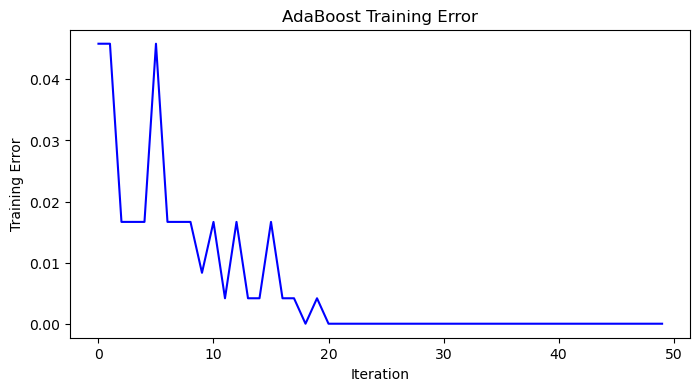

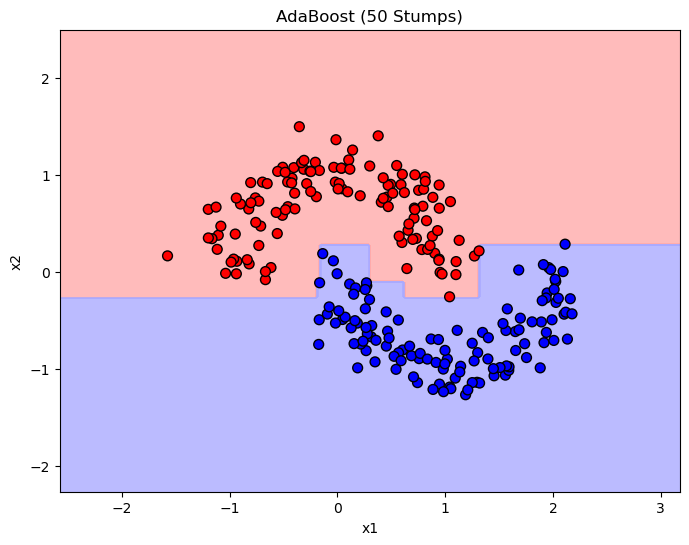

In [190]:
class DecisionStump:
    """A depth-1 decision tree for AdaBoost."""
    def __init__(self):
        self.feature = None; self.threshold = None; self.polarity = 1

    def fit(self, X, y, sample_weights=None):
        n, d = X.shape
        if sample_weights is None: sample_weights = np.ones(n) / n
        min_err = float('inf')
        for feat in range(d):
            for thr in np.unique(X[:, feat]):
                for pol in [1, -1]:
                    pred = np.ones(n)
                    if pol == 1: pred[X[:, feat] <= thr] = -1
                    else: pred[X[:, feat] > thr] = -1
                    err = np.sum(sample_weights[pred != y])
                    if err < min_err:
                        min_err = err
                        self.feature, self.threshold, self.polarity = feat, thr, pol
        return self

    def predict(self, X):
        pred = np.ones(X.shape[0])
        if self.polarity == 1:
            pred[X[:, self.feature] <= self.threshold] = -1
        else:
            pred[X[:, self.feature] > self.threshold] = -1
        return pred

class AdaBoost:
    """AdaBoost with decision stumps."""
    def __init__(self, n_estimators=50, learning_rate=1.0):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.stumps = []
        self.alphas = []
        self.training_errors = []

    def fit(self, X, y):
        n = len(y)
        w = np.ones(n) / n
        self.stumps = []; self.alphas = []
        for t in range(self.n_estimators):
            stump = DecisionStump()
            stump.fit(X, y, w)
            pred = stump.predict(X)
            err = np.sum(w[pred != y])
            err = max(min(err, 1 - 1e-10), 1e-10)
            alpha = 0.5 * np.log((1 - err) / err) * self.lr
            w = w * np.exp(-alpha * y * pred)
            w = w / np.sum(w)
            self.stumps.append(stump)
            self.alphas.append(alpha)
            train_pred = self.predict(X)
            self.training_errors.append(np.mean(train_pred != y))
        return self

    def predict(self, X):
        scores = np.zeros(X.shape[0])
        for alpha, stump in zip(self.alphas, self.stumps):
            scores += alpha * stump.predict(X)
        return np.sign(scores)

# Demo
y_ab_tr = np.where(y_m_tr == 0, -1, 1)
y_ab_te = np.where(y_m_te == 0, -1, 1)

ab = AdaBoost(n_estimators=50, learning_rate=1.0)
ab.fit(X_m_tr, y_ab_tr)
print(f'AdaBoost - Train Acc: {accuracy(y_ab_tr, ab.predict(X_m_tr)):.4f}')
print(f'AdaBoost - Test  Acc: {accuracy(y_ab_te, ab.predict(X_m_te)):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ab.training_errors, 'b-')
ax.set_xlabel('Iteration'); ax.set_ylabel('Training Error')
ax.set_title('AdaBoost Training Error')
plt.show()

class ABWrapper:
    def __init__(self, ab): self.ab = ab
    def predict(self, X): return np.where(self.ab.predict(X) == -1, 0, 1)

plot_decision_boundary(X_m_tr, y_m_tr, ABWrapper(ab), title='AdaBoost (50 Stumps)')

### 5.4 Gradient Boosting

1. Initialize $F_0(x) = \text{mean}(y)$
2. For each $t$: compute pseudo-residuals $r_i = y_i - F(x_i)$, fit tree to residuals, update $F \leftarrow F + \eta \cdot h_t$

#### Intuition: Gradient Descent in Function Space

Gradient Boosting is one of the most powerful and elegant ideas in machine learning:

> **Instead of doing gradient descent in parameter space (like neural networks), do gradient descent in *function space*.**

**The key insight:** Any ensemble $F(x) = \sum_t \eta \cdot h_t(x)$ can be built incrementally. At each step, we ask: "What function should I add to reduce the remaining error?"

**Step by step:**
1. **Initialize** with a constant prediction: $F_0(x) = \text{mean}(y)$ (the best constant predictor for MSE).
2. **Compute pseudo-residuals:** $r_i = y_i - F(x_i)$. These are the *negative gradients* of the loss with respect to the predictions.
3. **Fit a regression tree to the residuals** — it learns to predict *where the current model is wrong and by how much*.
4. **Update:** $F \leftarrow F + \eta \cdot h_t$. The learning rate $\eta$ (shrinkage) controls how much each tree contributes.
5. Repeat.

**Why "gradient"?** The pseudo-residuals $r_i = y_i - F(x_i)$ are exactly $-\nabla_{F} \text{Loss}$ for squared loss. For other losses (logistic, Huber), we just compute different gradients. Gradient Boosting = gradient descent in function space.

**The learning rate (shrinkage):** A small $\eta$ means each tree makes a small correction. This slows learning but dramatically improves generalization — it's like taking small, careful steps down the loss landscape. Combined with many trees, this "slow learning" produces remarkably accurate models.

**Gradient Boosting vs AdaBoost:**
- AdaBoost: uses exponential loss, focuses on hard samples via reweighting.
- Gradient Boosting: uses any differentiable loss, fits models to gradients (residuals).
- Gradient Boosting is more general and typically more accurate.

**This is the foundation of XGBoost, LightGBM, and CatBoost** — the dominant methods in tabular data competitions and industry.

Gradient Boosting - Train Acc: 0.9875
Gradient Boosting - Test  Acc: 0.9333


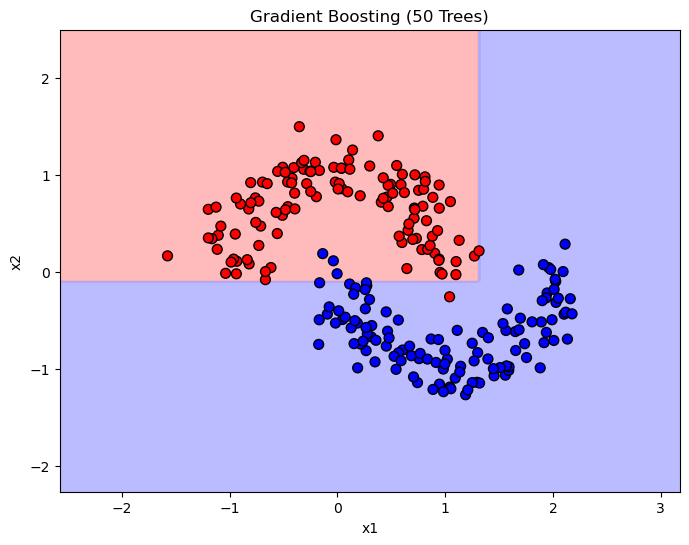

In [191]:
class GradientBoostingClassifierScratch:
    """Gradient Boosting for binary classification (logistic loss)."""
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3, seed=42):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.rng = np.random.RandomState(seed)
        self.trees = []
        self.init_logit = None

    def _sigmoid(self, z):
        return sigmoid(z)

    def fit(self, X, y):
        # Convert to {0, 1}
        y01 = (y + 1) // 2  # assumes y in {-1, 1}
        self.init_logit = np.log(y01.mean() / (1 - y01.mean() + 1e-10) + 1e-10)
        F = np.full(len(y), self.init_logit)
        self.trees = []
        for t in range(self.n_estimators):
            p = self._sigmoid(F)
            # Pseudo-residuals for logistic loss: y - p
            residuals = y01 - p
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residuals)
            update = tree.predict(X)
            F += self.lr * update
            self.trees.append(tree)
        return self

    def predict(self, X):
        F = np.full(X.shape[0], self.init_logit)
        for tree in self.trees:
            F += self.lr * tree.predict(X)
        return np.where(self._sigmoid(F) >= 0.5, 1, -1)

# Demo
gb = GradientBoostingClassifierScratch(n_estimators=50, learning_rate=0.1, max_depth=3, seed=42)
gb.fit(X_m_tr, y_ab_tr)
print(f'Gradient Boosting - Train Acc: {accuracy(y_ab_tr, gb.predict(X_m_tr)):.4f}')
print(f'Gradient Boosting - Test  Acc: {accuracy(y_ab_te, gb.predict(X_m_te)):.4f}')

class GBWrapper:
    def __init__(self, gb): self.gb = gb
    def predict(self, X): return np.where(self.gb.predict(X) == -1, 0, 1)

plot_decision_boundary(X_m_tr, y_m_tr, GBWrapper(gb), title='Gradient Boosting (50 Trees)')

### 5.5 Comparison of All Methods

Let's compare all classifiers on the same dataset.

#### Intuition: When to Use What

| Method | Reduces Bias or Variance? | Best When... |
|---|---|---|
| **Single Tree** | — | Interpretability is key, small datasets |
| **Bagging** | Variance | High-variance base models (deep trees) |
| **Random Forest** | Variance (+ decorrelation) | Default "off-the-shelf" choice, robust |
| **AdaBoost** | Bias | Weak learners, clean data, focus on hard examples |
| **Gradient Boosting** | Bias | Maximum accuracy, tabular data, enough data |

**The bias-variance perspective:**
- **Bagging/RF:** Start with low-bias, high-variance models (deep trees). Average to reduce variance.
- **Boosting:** Start with high-bias, low-variance models (shallow trees/stumps). Sequentially reduce bias.

**Practical advice:**
- For structured/tabular data: **Gradient Boosting** (or XGBoost) usually wins.
- For quick baselines: **Random Forest** — minimal tuning needed.
- For interpretability: **Single Decision Tree** or **AdaBoost** with stumps.

Model                      Train Acc   Test Acc
-----------------------------------------------
Logistic Regression           0.9583     0.9000
Decision Tree (d=5)           0.9917     0.9333
Decision Tree (d=15)          1.0000     0.9333
Bagging                       0.9875     0.9333
Random Forest                 0.9917     0.9333
AdaBoost                      1.0000     1.0000
Gradient Boosting             0.9875     0.9333


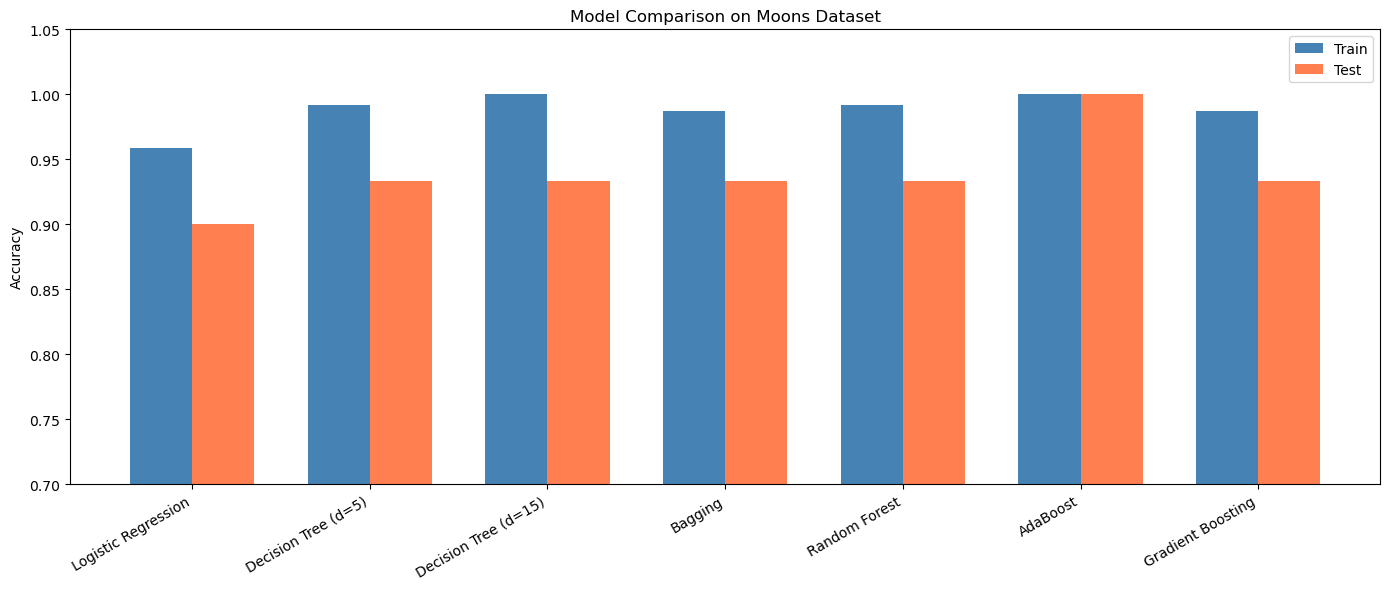

In [192]:
class Wrapper:
    """Wrapper to convert {-1,+1} predictions to {0,1}."""
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return np.where(self.model.predict(X) == -1, 0, 1)

models = {
    'Logistic Regression': LogisticRegression(learning_rate=0.1, n_epochs=500),
    'Decision Tree (d=5)': DecisionTreeClassifier(max_depth=5),
    'Decision Tree (d=15)': DecisionTreeClassifier(max_depth=15),
    'Bagging': BaggingClassifier(n_estimators=20, max_depth=5, seed=42),
    'Random Forest': RandomForestClassifierScratch(n_estimators=30, max_depth=5, seed=42),
    'AdaBoost': Wrapper(AdaBoost(n_estimators=50)),
    'Gradient Boosting': Wrapper(GradientBoostingClassifierScratch(n_estimators=50, learning_rate=0.1, max_depth=3, seed=42)),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    if name in ('AdaBoost', 'Gradient Boosting'):
        model.model.fit(X_m_tr, y_ab_tr)
        tr = accuracy(y_ab_tr, model.model.predict(X_m_tr))
        te = accuracy(y_ab_te, model.model.predict(X_m_te))
    else:
        model.fit(X_m_tr, y_m_tr)
        tr = accuracy(y_m_tr, model.predict(X_m_tr))
        te = accuracy(y_m_te, model.predict(X_m_te))
    results[name] = (tr, te)

print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10}")
print('-' * 47)
for name, (tr, te) in results.items():
    print(f'{name:<25} {tr:10.4f} {te:10.4f}')

# Bar chart
names = list(results.keys())
train_accs = [results[n][0] for n in names]
test_accs = [results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(names))
width = 0.35
ax.bar(x - width/2, train_accs, width, label='Train', color='steelblue')
ax.bar(x + width/2, test_accs, width, label='Test', color='coral')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison on Moons Dataset')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()

---

## 6. The Perceptron

$$h(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x})$$

**Update rule:** $\mathbf{w} \leftarrow \mathbf{w} + y^{(i)} \mathbf{x}^{(i)}$ for misclassified points.

Converges if data is linearly separable.

#### Intuition: The First Learning Algorithm (1958, Rosenblatt)

The perceptron is the **grandfather of neural networks**. It was inspired by how neurons in the brain fire: if the weighted sum of inputs exceeds a threshold, the neuron "fires" (outputs +1); otherwise, it stays quiet (outputs -1).

**How it learns:** The perceptron makes predictions one sample at a time. When it gets a sample right, nothing happens. When it gets one wrong:
- If the true label is +1 but it predicted -1: **push the weights toward the input** ($\mathbf{w} \leftarrow \mathbf{w} + \mathbf{x}$).
- If the true label is -1 but it predicted +1: **push the weights away from the input** ($\mathbf{w} \leftarrow \mathbf{w} - \mathbf{x}$).

This is exactly what $\mathbf{w} \leftarrow \mathbf{w} + y^{(i)}\mathbf{x}^{(i)}$ does when $y \in \{-1, +1\}$.

**The Perceptron Convergence Theorem:** If the data is **linearly separable** (there exists a hyperplane that perfectly separates the classes), the perceptron is *guaranteed* to find such a hyperplane in a finite number of steps. This is a remarkable theoretical result.

**The fatal limitation:** If the data is *not* linearly separable (like the XOR problem), the perceptron will never converge — it will keep updating forever. This limitation caused the first "AI winter" until multi-layer networks (MLPs) were shown to overcome it.

**Relationship to logistic regression:** Both learn linear decision boundaries. But:
- Logistic regression minimizes cross-entropy (a smooth, convex objective) → always converges, gives calibrated probabilities.
- The perceptron uses a direct error-correction rule → only converges if separable, gives hard predictions (no probabilities).

Converged at epoch 4
Train Acc: 1.0000
Test  Acc: 1.0000


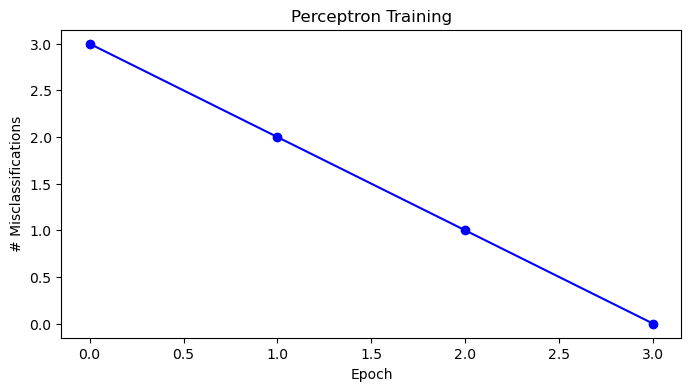

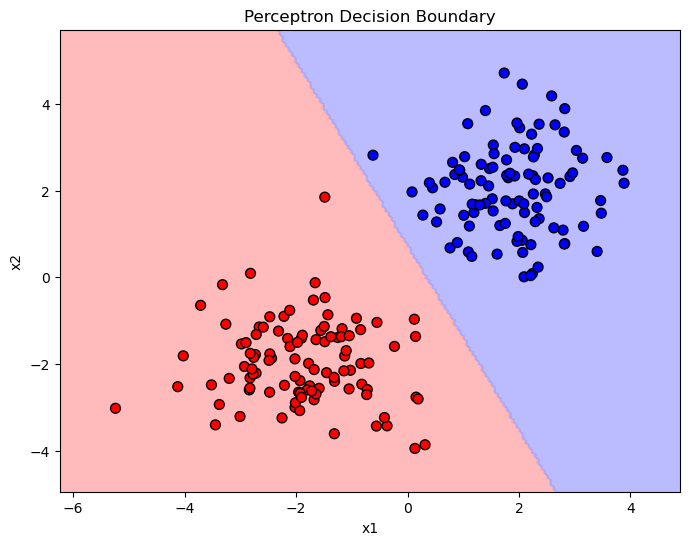

In [193]:
class Perceptron:
    def __init__(self, n_epochs=100, learning_rate=1.0):
        self.n_epochs = n_epochs
        self.lr = learning_rate
        self.w = None
        self.n_errors_history = []
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            errors = 0
            for i in range(n):
                pred = np.sign(self.w @ Xb[i])
                if pred == 0: pred = -1
                if pred != y[i]:
                    self.w += self.lr * y[i] * Xb[i]
                    errors += 1
            self.n_errors_history.append(errors)
            if errors == 0:
                print(f'Converged at epoch {epoch+1}')
                break
        return self
    def predict(self, X):
        preds = np.sign(add_bias_column(X) @ self.w)
        preds[preds == 0] = -1
        return preds

y_pm = np.where(y_clf == 0, -1, 1)
y_pm_train = np.where(y_clf_train == 0, -1, 1)
y_pm_test = np.where(y_clf_test == 0, -1, 1)

perceptron = Perceptron(n_epochs=100)
perceptron.fit(X_clf_train, y_pm_train)

print(f'Train Acc: {accuracy(y_pm_train, perceptron.predict(X_clf_train)):.4f}')
print(f'Test  Acc: {accuracy(y_pm_test, perceptron.predict(X_clf_test)):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(perceptron.n_errors_history, 'b-o')
ax.set_xlabel('Epoch'); ax.set_ylabel('# Misclassifications')
ax.set_title('Perceptron Training')
plt.show()

plot_decision_boundary(X_clf, y_clf, perceptron, title='Perceptron Decision Boundary')

---

## 7. Generalization

### 7.1 Overfitting & Underfitting Demo

We fit polynomials of different degrees to data from a quadratic function.

#### Intuition: The Central Tension in Machine Learning

**Generalization** is the ability of a model to perform well on **unseen data**, not just the training set. This is the *entire point* of machine learning — we don't care about training error, we care about test error.

The **bias-variance tradeoff** is the fundamental tension:

| | High Bias (Underfitting) | High Variance (Overfitting) |
|---|---|---|
| **Model complexity** | Too simple | Too complex |
| **Training error** | High | Low (near zero) |
| **Test error** | High | High |
| **Analogy** | A student who didn't study enough | A student who memorized the answers without understanding |
| **Fix** | Increase model complexity | More data, regularization, simpler model |

**Underfitting:** The model is too simple to capture the underlying pattern. A degree-1 polynomial (line) trying to fit quadratic data will always have systematic errors — it has high **bias**.

**Overfitting:** The model is so complex it fits the noise in the training data. A degree-20 polynomial can wiggle through every single training point perfectly, but those wiggles are memorizing noise, not learning signal — it has high **variance**.

**The sweet spot:** We want a model complex enough to capture the true pattern, but not so complex that it fits noise. This is typically found at the point where validation error is minimized.

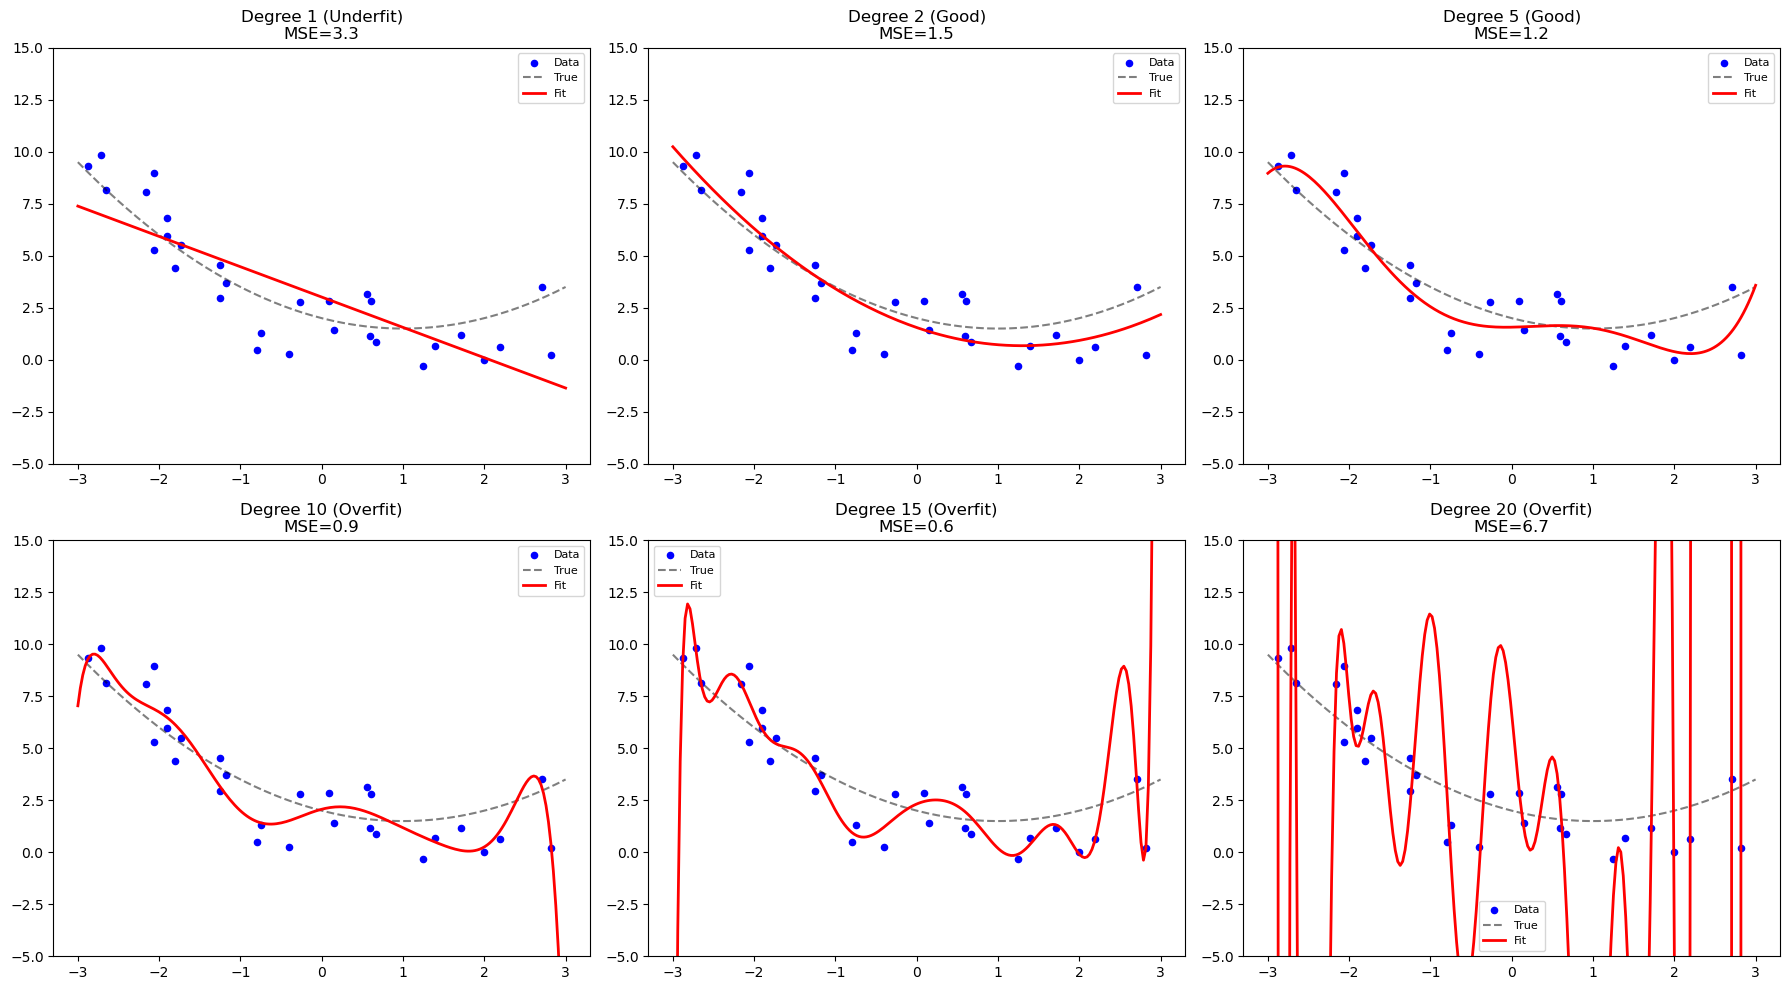

In [194]:
def polynomial_features(X, degree):
    X = X.reshape(-1, 1)
    return np.hstack([X ** d for d in range(1, degree + 1)])

rng = np.random.RandomState(42)
n = 30
X_poly_raw = rng.uniform(-3, 3, n)
y_poly = true_function(X_poly_raw) + rng.randn(n) * 1.5

degrees = [1, 2, 5, 10, 15, 20]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, deg in enumerate(degrees):
    ax = axes[idx // 3][idx % 3]
    X_pf = polynomial_features(X_poly_raw, deg)
    mean_pf = X_pf.mean(axis=0)
    std_pf = X_pf.std(axis=0); std_pf[std_pf == 0] = 1
    X_pf_s = (X_pf - mean_pf) / std_pf
    model = LinearRegressionClosedForm()
    model.fit(X_pf_s, y_poly)
    train_mse = mean_squared_error(y_poly, model.predict(X_pf_s))
    
    ax.scatter(X_poly_raw, y_poly, c='blue', s=20, label='Data')
    x_curve = np.linspace(-3, 3, 200)
    x_curve_pf = polynomial_features(x_curve, deg)
    x_curve_pf_s = (x_curve_pf - mean_pf) / std_pf
    ax.plot(x_curve, true_function(x_curve), 'k--', alpha=0.5, label='True')
    ax.plot(x_curve, model.predict(x_curve_pf_s), 'r-', linewidth=2, label='Fit')
    status = 'Underfit' if deg < 2 else ('Overfit' if deg > 5 else 'Good')
    ax.set_title(f'Degree {deg} ({status})\nMSE={train_mse:.1f}')
    ax.set_ylim(-5, 15); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 7.2 Bias-Variance Decomposition

#### Deep Understanding

The expected test error can be mathematically decomposed into three parts:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Bias²**: How much the *average* prediction differs from the true value. High bias means the model systematically gets it wrong (underfitting).
- **Variance**: How much individual predictions *fluctuate* across different training sets. High variance means the model is overly sensitive to the specific training data (overfitting).
- **Irreducible error**: The noise in the data itself. Even the perfect model can't predict this.

**The experiment below** trains many models on different random training sets and measures:
- **Bias²**: $E[(\bar{f}(x) - y)^2]$ — squared difference between the average prediction and the truth.
- **Variance**: $E[(f(x) - \bar{f}(x))^2]$ — how much each model's prediction varies around the average.

**The U-shaped curve:** As model complexity increases:
- Bias decreases (the model can represent more complex patterns).
- Variance increases (the model becomes more sensitive to training data noise).
- Total error first decreases, then increases — forming a U-shape.
- The optimal complexity is at the bottom of the U.

**Why ensembles work:** The key insight that enables bagging and random forests is that **averaging reduces variance** without increasing bias. If you average $B$ independent models, variance drops by a factor of $B$. This is why averaging many decision trees (Random Forest) works so well.

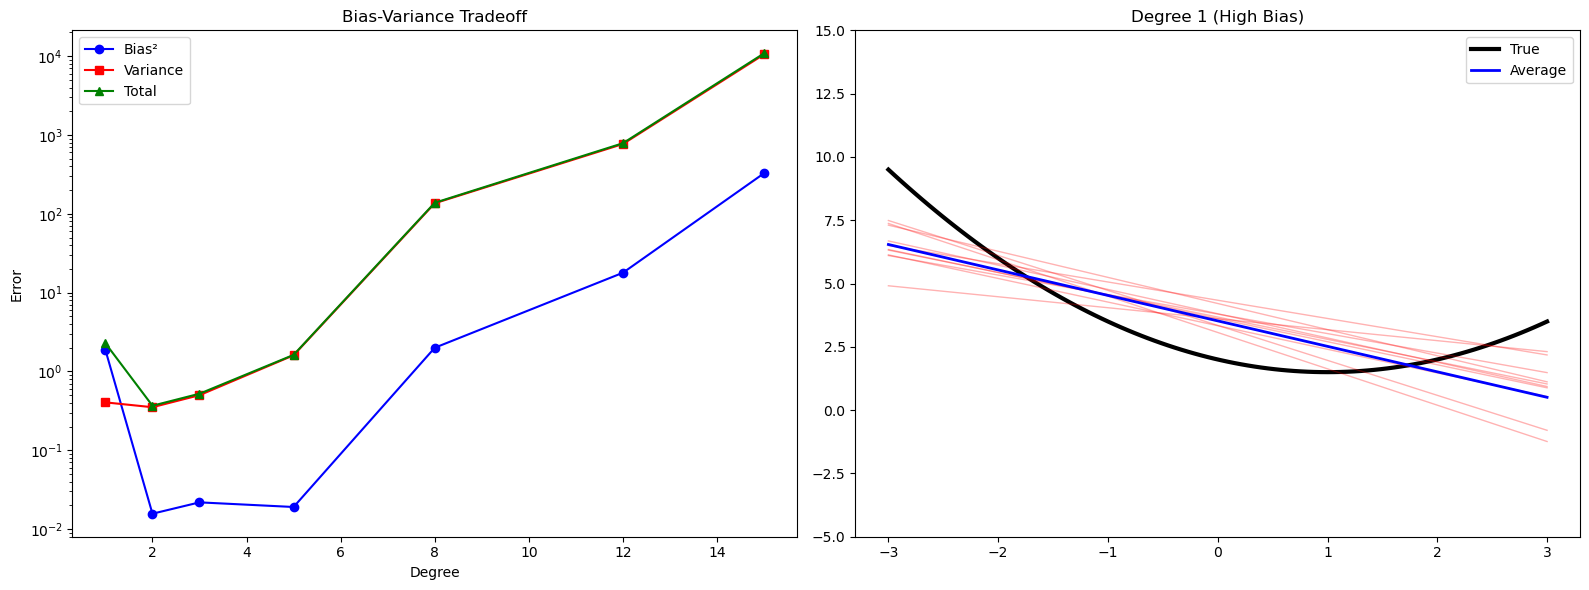

  Degree      Bias²   Variance      Total
------------------------------------------
       1     1.8730     0.4049     2.2780
       2     0.0157     0.3515     0.3672
       3     0.0218     0.4996     0.5214
       5     0.0191     1.6018     1.6208
       8     1.9964   135.9519   137.9484
      12    17.8535   767.5638   785.4172
      15   327.0344 10519.9305 10846.9649


In [195]:
def bias_variance_experiment(degree, n_models=50, n_train=25, seed=42):
    rng = np.random.RandomState(seed)
    x_test = np.linspace(-3, 3, 100)
    y_true = true_function(x_test)
    all_preds = np.zeros((n_models, len(x_test)))
    for m in range(n_models):
        X_tr = rng.uniform(-3, 3, n_train)
        y_tr = true_function(X_tr) + rng.randn(n_train) * 1.5
        X_tr_pf = polynomial_features(X_tr, degree)
        X_te_pf = polynomial_features(x_test, degree)
        mean = X_tr_pf.mean(axis=0)
        std = X_tr_pf.std(axis=0); std[std == 0] = 1
        X_tr_pf = (X_tr_pf - mean) / std
        X_te_pf = (X_te_pf - mean) / std
        Xb_tr = add_bias_column(X_tr_pf)
        Xb_te = add_bias_column(X_te_pf)
        lam = 1e-5
        w = np.linalg.inv(Xb_tr.T @ Xb_tr + lam * np.eye(Xb_tr.shape[1])) @ Xb_tr.T @ y_tr
        all_preds[m] = Xb_te @ w
    avg_pred = all_preds.mean(axis=0)
    bias_sq = np.mean((avg_pred - y_true) ** 2)
    variance = np.mean(np.var(all_preds, axis=0))
    return bias_sq, variance, bias_sq + variance, all_preds, avg_pred, x_test, y_true

degrees = [1, 2, 3, 5, 8, 12, 15]
results = [bias_variance_experiment(d) for d in degrees]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(degrees, [r[0] for r in results], 'b-o', label='Bias²')
axes[0].plot(degrees, [r[1] for r in results], 'r-s', label='Variance')
axes[0].plot(degrees, [r[2] for r in results], 'g-^', label='Total')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Error')
axes[0].set_title('Bias-Variance Tradeoff'); axes[0].legend(); axes[0].set_yscale('log')

# Show degree 1 (underfit)
_, _, _, preds, avg_p, x_t, y_t = results[0]
axes[1].plot(x_t, y_t, 'k-', linewidth=3, label='True')
for m in range(10):
    axes[1].plot(x_t, preds[m], alpha=0.3, linewidth=1, color='red')
axes[1].plot(x_t, avg_p, 'b-', linewidth=2, label='Average')
axes[1].set_title('Degree 1 (High Bias)'); axes[1].set_ylim(-5, 15)
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"{'Degree':>8} {'Bias²':>10} {'Variance':>10} {'Total':>10}")
print('-' * 42)
for i, d in enumerate(degrees):
    b, v, t = results[i][0], results[i][1], results[i][2]
    print(f'{d:8d} {b:10.4f} {v:10.4f} {t:10.4f}')

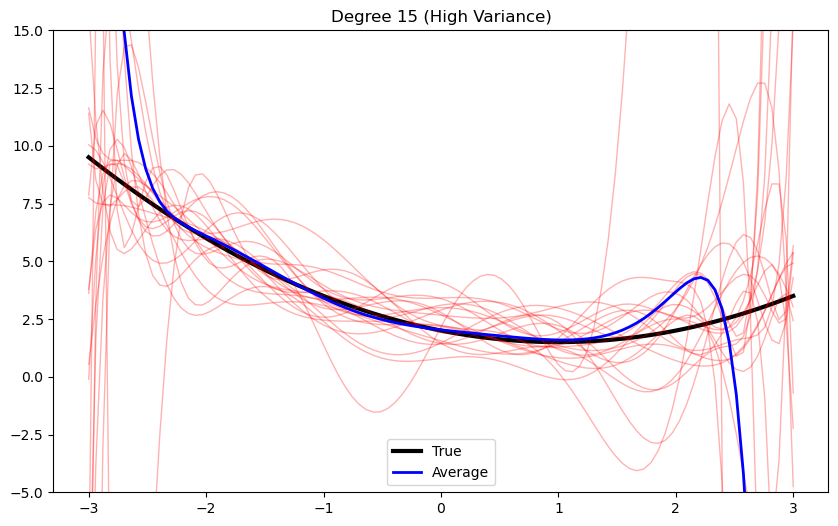

In [196]:
# Show degree 15 (overfit / high variance)
_, _, _, preds, avg_p, x_t, y_t = results[-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_t, y_t, 'k-', linewidth=3, label='True')
for m in range(20):
    ax.plot(x_t, preds[m], alpha=0.3, linewidth=1, color='red')
ax.plot(x_t, avg_p, 'b-', linewidth=2, label='Average')
ax.set_title('Degree 15 (High Variance)')
ax.set_ylim(-5, 15); ax.legend()
plt.show()

---

## 8. Regularization

### 8.1 Ridge Regression (L2)

$$J(\mathbf{w}) = \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda \|\mathbf{w}\|^2$$

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

#### Intuition: Penalizing Complexity

Regularization is the practical answer to overfitting. The idea is simple but powerful:

> **Add a penalty term to the cost function that discourages large weights.**

**L2 (Ridge) regularization** adds $\lambda \|\mathbf{w}\|^2 = \lambda \sum_j w_j^2$ to the loss. This:
- **Shrinks all weights toward zero** (but never exactly zero).
- Prevents any single feature from dominating.
- Makes $\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I}$ always invertible (fixes the singularity problem!).

**The $\lambda$ knob:**
- $\lambda = 0$: No regularization → pure OLS, can overfit.
- $\lambda \to \infty$: All weights → 0 → underfitting (predict the mean).
- Optimal $\lambda$: Found via cross-validation.

**Bayesian interpretation:** L2 regularization corresponds to placing a **Gaussian prior** on the weights — we believe weights should be small unless the data strongly says otherwise. This is Maximum A Posteriori (MAP) estimation.

**Geometric interpretation:** Ridge regression constrains the weight vector to lie within a **ball** (sphere) of radius determined by $\lambda$. The solution is the point on this ball that minimizes the SSE.

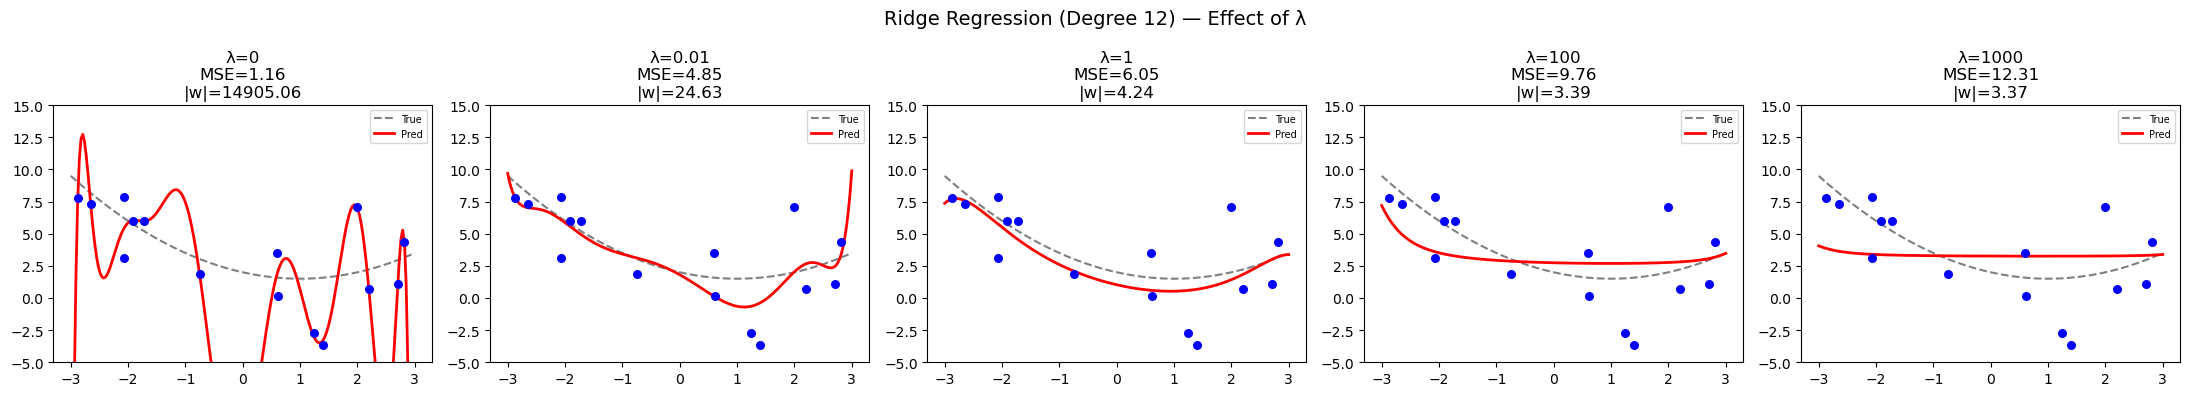

In [197]:
class RidgeRegression:
    def __init__(self, l2_lambda=1.0):
        self.l2_lambda = l2_lambda
        self.w = None
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        reg = self.l2_lambda * np.eye(d)
        reg[0, 0] = 0  # don't penalize bias
        self.w = np.linalg.inv(Xb.T @ Xb + reg) @ Xb.T @ y
        return self
    def predict(self, X):
        return add_bias_column(X) @ self.w

# Demo: Ridge on high-degree polynomial with small data
rng = np.random.RandomState(42)
n_s = 15
X_s = rng.uniform(-3, 3, n_s)
y_s = true_function(X_s) + rng.randn(n_s) * 2

deg = 12
X_pf = polynomial_features(X_s, deg)
mean_pf = X_pf.mean(axis=0)
std_pf = X_pf.std(axis=0); std_pf[std_pf == 0] = 1
X_pf_s = (X_pf - mean_pf) / std_pf

lambdas = [0, 0.01, 1, 100, 1000]
fig, axes = plt.subplots(1, len(lambdas), figsize=(22, 4))
for idx, lam in enumerate(lambdas):
    ax = axes[idx]
    model = RidgeRegression(l2_lambda=lam)
    model.fit(X_pf_s, y_s)
    train_mse = mean_squared_error(y_s, model.predict(X_pf_s))
    x_curve = np.linspace(-3, 3, 200)
    x_curve_pf = polynomial_features(x_curve, deg)
    x_curve_pf_s = (x_curve_pf - mean_pf) / std_pf
    ax.scatter(X_s, y_s, c='blue', s=30, zorder=5)
    ax.plot(x_curve, true_function(x_curve), 'k--', alpha=0.5, label='True')
    ax.plot(x_curve, model.predict(x_curve_pf_s), 'r-', linewidth=2, label='Pred')
    ax.set_title(f'λ={lam}\nMSE={train_mse:.2f}\n|w|={np.linalg.norm(model.w):.2f}')
    ax.set_ylim(-5, 15); ax.legend(fontsize=7)
plt.suptitle(f'Ridge Regression (Degree {deg}) — Effect of λ', fontsize=14)
plt.tight_layout()
plt.show()

### 8.2 Lasso Regression (L1) via Subgradient Descent

$$J(\mathbf{w}) = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda \|\mathbf{w}\|_1$$

#### Intuition: Sparse Solutions and Feature Selection

L1 regularization adds $\lambda \|\mathbf{w}\|_1 = \lambda \sum_j |w_j|$ to the loss. The crucial difference from L2:

> **L1 drives weights to exactly zero, performing automatic feature selection.**

**Why does L1 produce sparsity?** The geometric picture is key:
- L2 constrains weights to a **ball** (sphere). The SSE contours touch the sphere tangentially, so weights shrink but rarely hit zero.
- L1 constrains weights to a **diamond** (cross-polytope). The SSE contours are much more likely to touch the diamond at a **corner**, where some weights are exactly zero.

**Practical implications:**
- Lasso is ideal when you have many features but only a few are truly important.
- It produces **interpretable models** — you can see exactly which features matter.
- The L1 penalty is not differentiable at $w_j = 0$, so we use the **subgradient** $\text{sign}(w_j)$.

**L1 vs L2 summary:**

| Property | L1 (Lasso) | L2 (Ridge) |
|---|---|---|
| Penalty | $\lambda \sum |w_j|$ | $\lambda \sum w_j^2$ |
| Sparsity | Yes (drives weights to 0) | No (shrinks but keeps all) |
| Feature selection | Automatic | No |
| Solution | Non-linear in $\mathbf{y}$, no closed form | Closed form via normal equation |
| Geometry | Diamond constraint | Ball constraint |

In [198]:
class LassoRegression:
    def __init__(self, l1_lambda=1.0, learning_rate=0.01, n_epochs=2000):
        self.l1_lambda = l1_lambda
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None
    def fit(self, X, y):
        Xb = add_bias_column(X)
        n, d = Xb.shape
        self.w = np.zeros(d)
        for epoch in range(self.n_epochs):
            y_pred = Xb @ self.w
            grad = Xb.T @ (y_pred - y) / n
            sub_l1 = np.sign(self.w); sub_l1[0] = 0
            grad += (self.l1_lambda / n) * sub_l1
            self.w -= self.lr * grad
        return self
    def predict(self, X):
        return add_bias_column(X) @ self.w

X_mv, y_mv = make_multivariate_regression(n=100, d=5, noise=2, seed=42)
X_mv_tr, X_mv_te, y_mv_tr, y_mv_te = train_test_split(X_mv, y_mv, 0.2, seed=42)
X_mv_tr_s, X_mv_te_s, _, _ = standardize(X_mv_tr, X_mv_te)

print(f'{"λ":>8} {"w0":>8} {"w1":>8} {"w2":>8} {"w3":>8} {"w4":>8} {"w5":>8} {"#zeros":>8}')
print('-' * 66)
for lam in [0, 0.1, 1, 5, 10, 50]:
    lasso = LassoRegression(l1_lambda=lam, learning_rate=0.01, n_epochs=3000)
    lasso.fit(X_mv_tr_s, y_mv_tr)
    nz = np.sum(np.abs(lasso.w[1:]) < 1e-4)
    ws = ' '.join([f'{x:8.3f}' for x in lasso.w])
    print(f'{lam:8.1f} {ws} {nz:8d}')

       λ       w0       w1       w2       w3       w4       w5   #zeros
------------------------------------------------------------------
     0.0    0.769    2.011   -0.797    0.553    1.025   -0.352        0
     0.1    0.769    2.010   -0.796    0.551    1.024   -0.351        0
     1.0    0.769    2.002   -0.784    0.536    1.011   -0.340        0
     5.0    0.769    1.963   -0.729    0.471    0.956   -0.290        0
    10.0    0.769    1.915   -0.661    0.390    0.887   -0.228        0
    50.0    0.769    1.496   -0.148    0.006    0.354   -0.009        0


### 8.3 Cross-Validation for $\lambda$ Selection

#### Intuition: Don't Touch the Test Set

How do we choose the best $\lambda$? We can't use the test set for this — that would be cheating (the test set must remain unseen until the very end). Instead, we use **k-fold cross-validation**:

1. **Split** the training data into $k$ equal folds.
2. **For each fold $i$:** Train on the other $k-1$ folds, evaluate on fold $i$.
3. **Average** the $k$ validation errors → this is your estimate of generalization error.

**Why it works:** Every sample gets to be in a validation set exactly once, and in a training set $k-1$ times. This gives a robust estimate of how the model will perform on unseen data.

**The $\lambda$ sweep:** We try many values of $\lambda$ (typically on a log scale), run CV for each, and pick the one with the lowest average validation error. The plot typically shows a U-shaped curve — too little regularization → overfitting, too much → underfitting.

**5-fold or 10-fold CV** is the standard choice. More folds → less bias in the estimate but more computation.

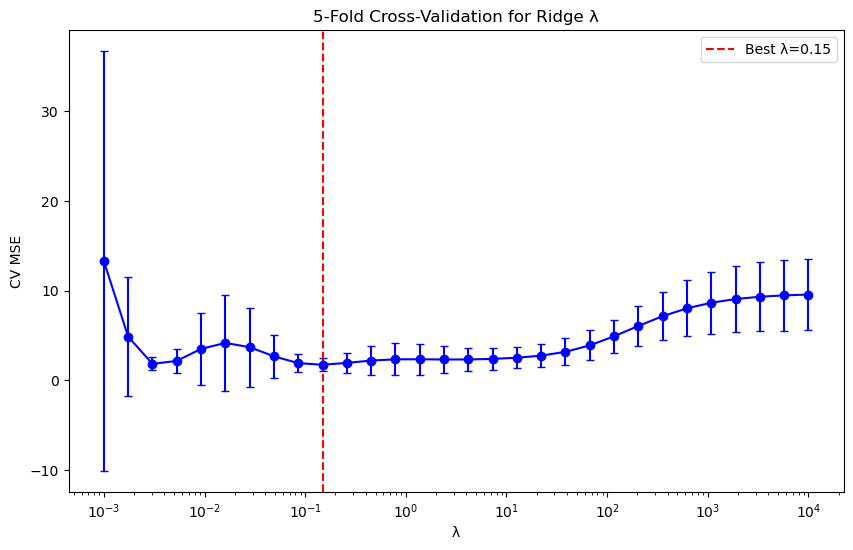

Best λ: 0.1487 (CV MSE: 1.7210)


In [199]:
def k_fold_cv(X, y, k=5, l2_lambda=0.0):
    n = len(y)
    idx = np.random.RandomState(42).permutation(n)
    fs = n // k
    errors = []
    for fold in range(k):
        s = fold * fs
        e = (fold+1)*fs if fold < k-1 else n
        val_idx = idx[s:e]
        tr_idx = np.concatenate([idx[:s], idx[e:]])
        m = RidgeRegression(l2_lambda=l2_lambda)
        m.fit(X[tr_idx], y[tr_idx])
        errors.append(mean_squared_error(y[val_idx], m.predict(X[val_idx])))
    return np.mean(errors), np.std(errors)

X_poly_cv = polynomial_features(X_poly_raw, 10)
X_poly_cv, _, _ = standardize(X_poly_cv)

lambdas_cv = np.logspace(-3, 4, 30)
cv_m, cv_s = zip(*[k_fold_cv(X_poly_cv, y_poly, k=5, l2_lambda=l) for l in lambdas_cv])
best_idx = np.argmin(cv_m)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(lambdas_cv, cv_m, yerr=cv_s, fmt='b-o', capsize=3)
ax.axvline(lambdas_cv[best_idx], color='r', linestyle='--', label=f'Best λ={lambdas_cv[best_idx]:.2f}')
ax.set_xscale('log'); ax.set_xlabel('λ'); ax.set_ylabel('CV MSE')
ax.set_title('5-Fold Cross-Validation for Ridge λ'); ax.legend()
plt.show()
print(f'Best λ: {lambdas_cv[best_idx]:.4f} (CV MSE: {cv_m[best_idx]:.4f})')

---

## 9. Multi-Layer Perceptron (MLP)

### 9.1 Activation Functions

### 9.1 Activation Functions

#### Why Non-linearity Matters

Without activation functions, a neural network — no matter how many layers — is just a linear transformation. $\mathbf{W}_2(\mathbf{W}_1\mathbf{x}) = \mathbf{W}'\mathbf{x}$. The composition of linear functions is linear. **Activation functions introduce non-linearity**, which is what gives neural networks their universal approximation power.

| Activation | Formula | Pros | Cons |
|---|---|---|---|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | Smooth, outputs in (0,1) | Vanishing gradients, not zero-centered |
| **Tanh** | $\tanh(z)$ | Zero-centered, stronger gradients than sigmoid | Still saturates |
| **ReLU** | $\max(0, z)$ | No saturation for positive inputs, computationally cheap | "Dying ReLU" — neurons can permanently output 0 |
| **Leaky ReLU** | $\max(0.01z, z)$ | Fixes dying ReLU | Slightly more complex |

**The vanishing gradient problem:** Sigmoid and tanh squash inputs to a small range. Their derivatives are at most 0.25 and 1.0 respectively, and approach 0 for large inputs. In deep networks, these small derivatives multiply across layers during backpropagation, causing gradients to **vanish** — early layers barely learn.

**ReLU's breakthrough:** ReLU has gradient 1 for positive inputs and 0 for negative. This means gradients don't vanish for active neurons, enabling training of much deeper networks. This was one of the key insights that made deep learning practical.

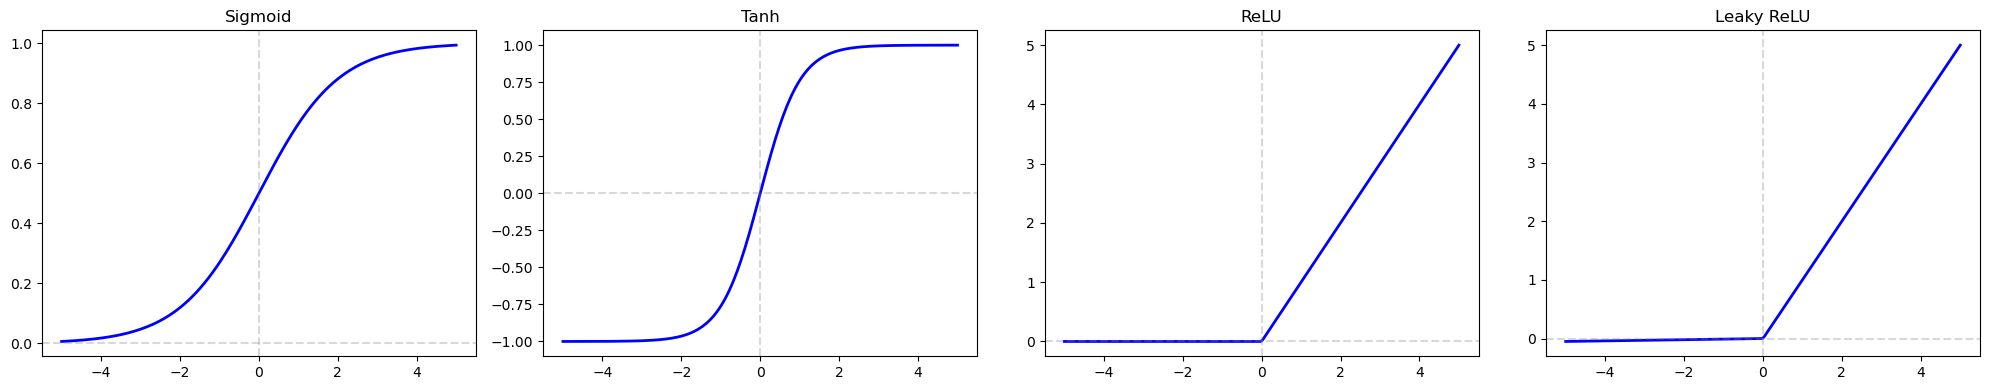

In [200]:
def relu(z): return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(float)
def tanh_fn(z): return np.tanh(z)
def tanh_deriv(z): return 1 - np.tanh(z)**2
def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, fn, name in [(axes[0], sigmoid, 'Sigmoid'), (axes[1], tanh_fn, 'Tanh'),
                      (axes[2], relu, 'ReLU'), (axes[3], lambda z: np.maximum(0.01*z, z), 'Leaky ReLU')]:
    ax.plot(z, fn(z), 'b-', linewidth=2)
    ax.set_title(name); ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout(); plt.show()

### 9.2 MLP for Binary Classification (with Backpropagation & Dropout)

#### Intuition: Learning Hierarchical Representations

A Multi-Layer Perceptron (MLP) chains together linear transformations and non-linear activations:

$$\mathbf{a}_1 = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1), \quad \mathbf{a}_2 = \sigma(\mathbf{W}_2 \mathbf{a}_1 + \mathbf{b}_2), \quad \hat{y} = \sigma(\mathbf{W}_3 \mathbf{a}_2 + \mathbf{b}_3)$$

Each layer learns a **transformation** of the data. The first layer might learn simple features (edges, curves), the second layer combines them into more complex patterns, and so on. This hierarchical feature learning is what makes neural networks so powerful.

**Backpropagation** is just the **chain rule** applied efficiently. The key insight:
- Compute the error at the output layer.
- Propagate it *backward* through the network, multiplying by the weight matrices and activation derivatives.
- Each layer's gradient is computed in terms of the next layer's gradient.

**The forward pass** stores intermediate values (activations and pre-activations) that are reused in the backward pass. This makes backpropagation much more efficient than computing each gradient independently.

**Mini-batch gradient descent** processes small batches (e.g., 32 samples), computing the average gradient over the batch. This balances computational efficiency with gradient stability.

**Dropout** randomly "drops" (zeros out) a fraction of neurons during training. This forces the network to not rely on any single neuron, creating **redundant representations**. At test time, all neurons are used (scaled appropriately). It's like training an ensemble of sub-networks within a single network.

In [201]:
class MLPClassifier:
    """
    MLP for Binary Classification.
    Forward: z = Wa + b; a = activation(z)
    Backward: chain rule to compute gradients
    Loss: Binary cross-entropy
    Supports: L2 regularization, Dropout
    """
    def __init__(self, hidden_sizes=[64], learning_rate=0.01, n_epochs=200,
                 batch_size=32, activation='relu', l2_lambda=0.0, dropout_rate=0.0, seed=42):
        self.hidden_sizes = hidden_sizes
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.activation = activation
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        self.rng = np.random.RandomState(seed)
        self.weights = []
        self.biases = []
        self.cost_history = []

    def _init_params(self, n_features, n_output=1):
        sizes = [n_features] + self.hidden_sizes + [n_output]
        self.weights = []
        self.biases = []
        for i in range(len(sizes) - 1):
            scale = np.sqrt(2.0 / sizes[i]) if self.activation == 'relu' else np.sqrt(1.0 / sizes[i])
            self.weights.append(self.rng.randn(sizes[i], sizes[i+1]) * scale)
            self.biases.append(np.zeros((1, sizes[i+1])))

    def _act(self, z, is_output):
        if is_output: return sigmoid(z)
        if self.activation == 'relu': return relu(z)
        elif self.activation == 'tanh': return tanh_fn(z)
        else: return sigmoid(z)

    def _act_deriv(self, z, is_output):
        if is_output:
            s = sigmoid(z); return s * (1 - s)
        if self.activation == 'relu': return relu_deriv(z)
        elif self.activation == 'tanh': return tanh_deriv(z)
        else: return sigmoid_deriv(z)

    def _forward(self, X, training=False):
        a = X
        activations = [a]
        zs = []
        masks = []
        for i in range(len(self.weights)):
            is_out = (i == len(self.weights) - 1)
            z = a @ self.weights[i] + self.biases[i]
            zs.append(z)
            a = self._act(z, is_out)
            if training and self.dropout_rate > 0 and not is_out:
                mask = (self.rng.rand(*a.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                a = a * mask
                masks.append(mask)
            else:
                masks.append(None)
            activations.append(a)
        return activations, zs, masks

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        n, d = X.shape
        self._init_params(d, 1)
        y2 = y.reshape(-1, 1)
        for epoch in range(self.n_epochs):
            perm = self.rng.permutation(n)
            Xs, ys = X[perm], y2[perm]
            for start in range(0, n, self.batch_size):
                Xb = Xs[start:start+self.batch_size]
                yb = ys[start:start+self.batch_size]
                m = len(yb)
                acts, zs, masks = self._forward(Xb, training=True)
                deltas = [None] * len(self.weights)
                deltas[-1] = (acts[-1] - yb) / m
                for i in range(len(self.weights)-2, -1, -1):
                    d = deltas[i+1] @ self.weights[i+1].T * self._act_deriv(zs[i], False)
                    if masks[i] is not None: d = d * masks[i]
                    deltas[i] = d
                for i in range(len(self.weights)):
                    gW = acts[i].T @ deltas[i]
                    gb = np.sum(deltas[i], axis=0, keepdims=True)
                    if self.l2_lambda > 0:
                        gW += (self.l2_lambda / m) * self.weights[i]
                    self.weights[i] -= self.lr * gW
                    self.biases[i] -= self.lr * gb
            acts, _, _ = self._forward(X)
            out = acts[-1].ravel()
            eps = 1e-12
            loss = -np.mean(y * np.log(out + eps) + (1 - y) * np.log(1 - out + eps))
            self.cost_history.append(loss)
            if verbose and (epoch % 50 == 0 or epoch == self.n_epochs - 1):
                msg = f'Epoch {epoch:4d}: loss={loss:.4f}'
                if X_val is not None:
                    msg += f', val_acc={accuracy(y_val, self.predict(X_val)):.4f}'
                print(msg)
        return self

    def predict_proba(self, X):
        return self._forward(X)[0][-1].ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print('MLPClassifier defined.')

MLPClassifier defined.


Epoch    0: loss=0.4772, val_acc=0.8333
Epoch   50: loss=0.0706, val_acc=0.9167
Epoch  100: loss=0.0460, val_acc=0.9500
Epoch  150: loss=0.0228, val_acc=0.9833
Epoch  200: loss=0.0117, val_acc=0.9833
Epoch  250: loss=0.0069, val_acc=0.9833
Epoch  299: loss=0.0046, val_acc=1.0000

Train Acc: 1.0000
Test  Acc: 1.0000


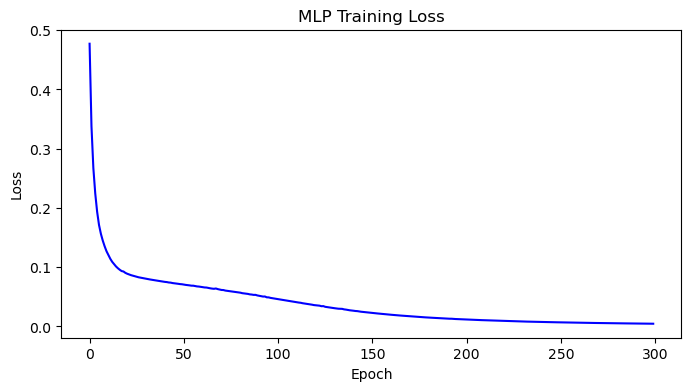

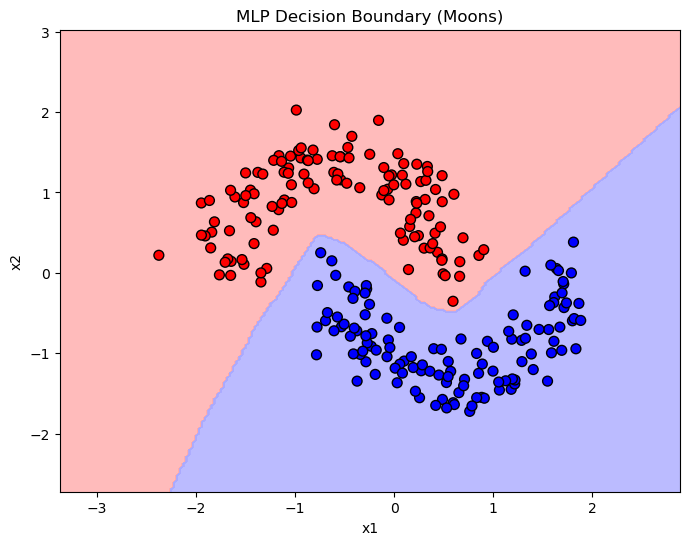

In [202]:
# Demo: MLP on Moons
X_moons, y_moons = make_moons(n=300, noise=0.2, seed=42)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(X_moons, y_moons, 0.2, seed=42)
X_m_tr_s, X_m_te_s, _, _ = standardize(X_m_tr, X_m_te)

mlp = MLPClassifier(hidden_sizes=[16, 8], learning_rate=0.1, n_epochs=300,
                     batch_size=32, activation='relu', l2_lambda=0.001, seed=42)
mlp.fit(X_m_tr_s, y_m_tr, X_val=X_m_te_s, y_val=y_m_te)

print(f'\nTrain Acc: {accuracy(y_m_tr, mlp.predict(X_m_tr_s)):.4f}')
print(f'Test  Acc: {accuracy(y_m_te, mlp.predict(X_m_te_s)):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.cost_history, 'b-')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('MLP Training Loss')
plt.show()
plot_decision_boundary(X_m_tr_s, y_m_tr, mlp, title='MLP Decision Boundary (Moons)')

Epoch    0: loss=0.6617, val_acc=0.5167
Epoch   50: loss=0.0299, val_acc=0.9833
Epoch  100: loss=0.0109, val_acc=0.9833
Epoch  150: loss=0.0063, val_acc=0.9833
Epoch  200: loss=0.0042, val_acc=0.9833
Epoch  250: loss=0.0032, val_acc=0.9833
Epoch  299: loss=0.0025, val_acc=0.9833

Train Acc: 1.0000
Test  Acc: 0.9833


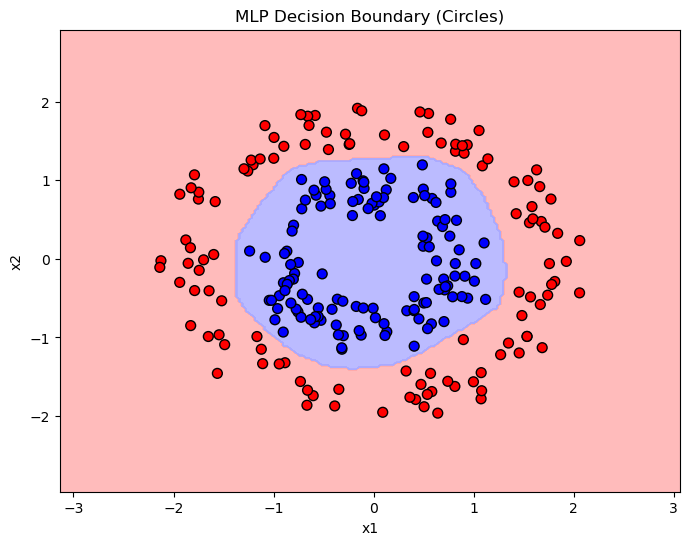

In [203]:
# MLP on Circles
X_circles, y_circles = make_circles(n=300, noise=0.1, factor=0.5, seed=42)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(X_circles, y_circles, 0.2, seed=42)
X_c_tr_s, X_c_te_s, _, _ = standardize(X_c_tr, X_c_te)

mlp_c = MLPClassifier(hidden_sizes=[32, 16], learning_rate=0.1, n_epochs=300,
                       batch_size=32, activation='relu', l2_lambda=0.001, seed=42)
mlp_c.fit(X_c_tr_s, y_c_tr, X_val=X_c_te_s, y_val=y_c_te)
print(f'\nTrain Acc: {accuracy(y_c_tr, mlp_c.predict(X_c_tr_s)):.4f}')
print(f'Test  Acc: {accuracy(y_c_te, mlp_c.predict(X_c_te_s)):.4f}')
plot_decision_boundary(X_c_tr_s, y_c_tr, mlp_c, title='MLP Decision Boundary (Circles)')

### 9.3 MLP for Regression

#### Intuition

For regression, the only change from classification is:
- **Output activation**: Linear (identity) instead of sigmoid.
- **Loss function**: Mean Squared Error instead of cross-entropy.

The MLP can now approximate any continuous function (Universal Approximation Theorem). Below, we fit $\sin(x)$ — a highly non-linear function that linear regression could never capture.

Epoch    0: MSE=0.5194
Epoch  100: MSE=0.0774
Epoch  200: MSE=0.0193
Epoch  300: MSE=0.0172
Epoch  400: MSE=0.0182
Epoch  499: MSE=0.0169

Train MSE: 0.0169
Test  MSE: 0.0211


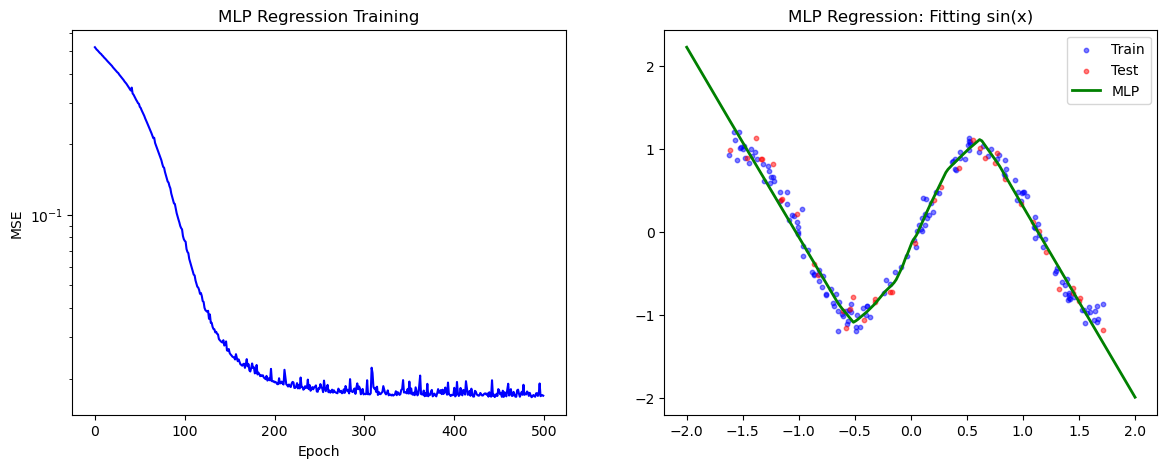

In [204]:
class MLPRegressor:
    """MLP for Regression. Output: linear. Loss: MSE."""
    def __init__(self, hidden_sizes=[32, 16], learning_rate=0.01, n_epochs=500,
                 batch_size=32, activation='relu', l2_lambda=0.0, seed=42):
        self.hidden_sizes = hidden_sizes
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.activation = activation
        self.l2_lambda = l2_lambda
        self.rng = np.random.RandomState(seed)
        self.weights = []
        self.biases = []
        self.cost_history = []

    def _init_params(self, n_features, n_output=1):
        sizes = [n_features] + self.hidden_sizes + [n_output]
        for i in range(len(sizes) - 1):
            scale = np.sqrt(2.0 / sizes[i]) if self.activation == 'relu' else np.sqrt(1.0 / sizes[i])
            self.weights.append(self.rng.randn(sizes[i], sizes[i+1]) * scale)
            self.biases.append(np.zeros((1, sizes[i+1])))

    def _act(self, z, is_out):
        if is_out: return z
        if self.activation == 'relu': return relu(z)
        elif self.activation == 'tanh': return tanh_fn(z)
        else: return sigmoid(z)

    def _act_deriv(self, z, is_out):
        if is_out: return np.ones_like(z)
        if self.activation == 'relu': return relu_deriv(z)
        elif self.activation == 'tanh': return tanh_deriv(z)
        else: return sigmoid_deriv(z)

    def _forward(self, X):
        a = X; acts = [a]; zs = []
        for i in range(len(self.weights)):
            z = a @ self.weights[i] + self.biases[i]
            zs.append(z)
            a = self._act(z, i == len(self.weights)-1)
            acts.append(a)
        return acts, zs

    def fit(self, X, y, verbose=True):
        n, d = X.shape
        self._init_params(d, 1)
        y2 = y.reshape(-1, 1)
        for epoch in range(self.n_epochs):
            perm = self.rng.permutation(n)
            Xs, ys = X[perm], y2[perm]
            for start in range(0, n, self.batch_size):
                Xb = Xs[start:start+self.batch_size]
                yb = ys[start:start+self.batch_size]
                m = len(yb)
                acts, zs = self._forward(Xb)
                deltas = [None] * len(self.weights)
                deltas[-1] = (2.0 / m) * (acts[-1] - yb)
                for i in range(len(self.weights)-2, -1, -1):
                    deltas[i] = deltas[i+1] @ self.weights[i+1].T * self._act_deriv(zs[i], False)
                for i in range(len(self.weights)):
                    gW = acts[i].T @ deltas[i]
                    gb = np.sum(deltas[i], axis=0, keepdims=True)
                    if self.l2_lambda > 0:
                        gW += (self.l2_lambda / m) * self.weights[i]
                    self.weights[i] -= self.lr * gW
                    self.biases[i] -= self.lr * gb
            acts, _ = self._forward(X)
            loss = np.mean((acts[-1].ravel() - y) ** 2)
            self.cost_history.append(loss)
            if verbose and (epoch % 100 == 0 or epoch == self.n_epochs - 1):
                print(f'Epoch {epoch:4d}: MSE={loss:.4f}')
        return self

    def predict(self, X):
        return self._forward(X)[0][-1].ravel()

# Demo: fit sin(x)
rng = np.random.RandomState(42)
n = 200
X_nl = rng.uniform(-5, 5, (n, 1))
y_nl = np.sin(X_nl[:, 0]) + 0.1 * rng.randn(n)

X_nl_tr, X_nl_te, y_nl_tr, y_nl_te = train_test_split(X_nl, y_nl, 0.2, seed=42)
X_nl_tr_s, X_nl_te_s, _, _ = standardize(X_nl_tr, X_nl_te)

mlp_reg = MLPRegressor(hidden_sizes=[32, 16], learning_rate=0.01, n_epochs=500,
                        batch_size=32, activation='relu', l2_lambda=0.0001, seed=42)
mlp_reg.fit(X_nl_tr_s, y_nl_tr)

print(f'\nTrain MSE: {mean_squared_error(y_nl_tr, mlp_reg.predict(X_nl_tr_s)):.4f}')
print(f'Test  MSE: {mean_squared_error(y_nl_te, mlp_reg.predict(X_nl_te_s)):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mlp_reg.cost_history, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title('MLP Regression Training'); axes[0].set_yscale('log')
axes[1].scatter(X_nl_tr_s, y_nl_tr, c='blue', s=10, alpha=0.5, label='Train')
axes[1].scatter(X_nl_te_s, y_nl_te, c='red', s=10, alpha=0.5, label='Test')
x_curve = np.linspace(-2, 2, 200).reshape(-1, 1)
axes[1].plot(x_curve, mlp_reg.predict(x_curve), 'g-', linewidth=2, label='MLP')
axes[1].set_title('MLP Regression: Fitting sin(x)')
axes[1].legend()
plt.show()

### 9.4 Effect of Dropout on Overfitting

#### Deep Understanding

Dropout is one of the most elegant regularization techniques in deep learning. The idea:

> **During each training step, randomly "turn off" a fraction of neurons. The remaining neurons must learn to work with whatever subset they're given.**

**Why it works:**
1. **Prevents co-adaptation:** Neurons can't rely on specific other neurons being present. Each neuron must learn useful features on its own.
2. **Model averaging:** Each training step effectively trains a different sub-network. At test time, using all neurons is like averaging over an exponentially large ensemble of sub-networks.
3. **Inverted dropout:** During training, we scale activations by $\frac{1}{1-p}$ so that the expected activation at test time matches training. This way, no scaling is needed at test time.

**The experiment below** compares a network without dropout (which overfits a small dataset) to one with dropout (which generalizes better).

Without dropout:
  Train Acc: 1.0000
  Test  Acc: 0.9500
With dropout (rate=0.3):
  Train Acc: 1.0000
  Test  Acc: 0.9750


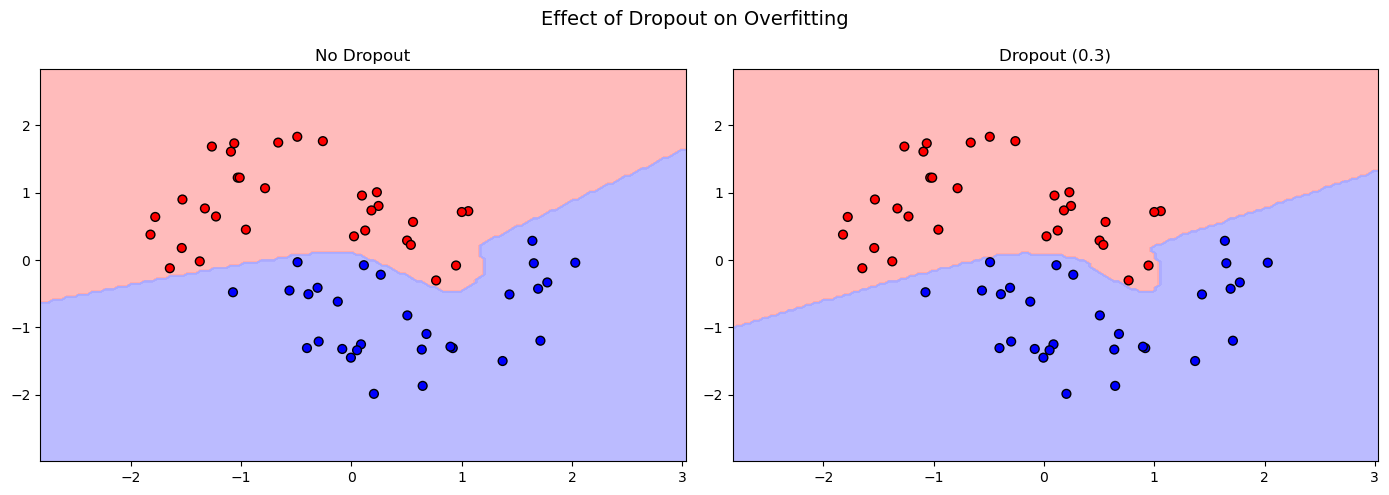

In [205]:
# Small dataset → prone to overfitting
X_of, y_of = make_moons(n=100, noise=0.3, seed=42)
X_of_tr, X_of_te, y_of_tr, y_of_te = train_test_split(X_of, y_of, 0.4, seed=42)
X_of_tr_s, X_of_te_s, _, _ = standardize(X_of_tr, X_of_te)

mlp_nd = MLPClassifier(hidden_sizes=[64, 64], learning_rate=0.1, n_epochs=400,
                        batch_size=16, activation='relu', l2_lambda=0.0,
                        dropout_rate=0.0, seed=42)
mlp_nd.fit(X_of_tr_s, y_of_tr, verbose=False)

mlp_d = MLPClassifier(hidden_sizes=[64, 64], learning_rate=0.1, n_epochs=400,
                       batch_size=16, activation='relu', l2_lambda=0.0,
                       dropout_rate=0.3, seed=42)
mlp_d.fit(X_of_tr_s, y_of_tr, verbose=False)

print('Without dropout:')
print(f'  Train Acc: {accuracy(y_of_tr, mlp_nd.predict(X_of_tr_s)):.4f}')
print(f'  Test  Acc: {accuracy(y_of_te, mlp_nd.predict(X_of_te_s)):.4f}')
print('With dropout (rate=0.3):')
print(f'  Train Acc: {accuracy(y_of_tr, mlp_d.predict(X_of_tr_s)):.4f}')
print(f'  Test  Acc: {accuracy(y_of_te, mlp_d.predict(X_of_te_s)):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in [(axes[0], mlp_nd, 'No Dropout'), (axes[1], mlp_d, 'Dropout (0.3)')]:
    xm, xM = X_of_tr_s[:,0].min()-1, X_of_tr_s[:,0].max()+1
    ym, yM = X_of_tr_s[:,1].min()-1, X_of_tr_s[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(xm, xM, 150), np.linspace(ym, yM, 150))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.8)
    ax.scatter(X_of_tr_s[:,0], X_of_tr_s[:,1], c=y_of_tr,
               cmap=ListedColormap(['#FF0000', '#0000FF']), edgecolors='k', s=40)
    ax.set_title(title)
plt.suptitle('Effect of Dropout on Overfitting', fontsize=14)
plt.tight_layout(); plt.show()

### 9.5 Early Stopping

#### Intuition

Early stopping is beautifully simple:

> **Monitor validation loss during training. Stop when it stops improving.**

During training, the model first learns useful patterns (both training and validation loss decrease). Then it starts memorizing noise (training loss keeps decreasing, but validation loss starts increasing). Early stopping catches this turning point.

**The patience parameter:** Validation loss can fluctuate. We don't want to stop at the first tiny increase. "Patience" = how many epochs of no improvement to tolerate before stopping.

**It's free regularization:** Early stopping doesn't change the model architecture or add penalty terms. It simply limits the number of gradient steps, which is itself a form of regularization. In fact, early stopping is mathematically equivalent to L2 regularization — more steps = less regularization.

Early stopping at epoch 35 (best val_loss=0.1723)


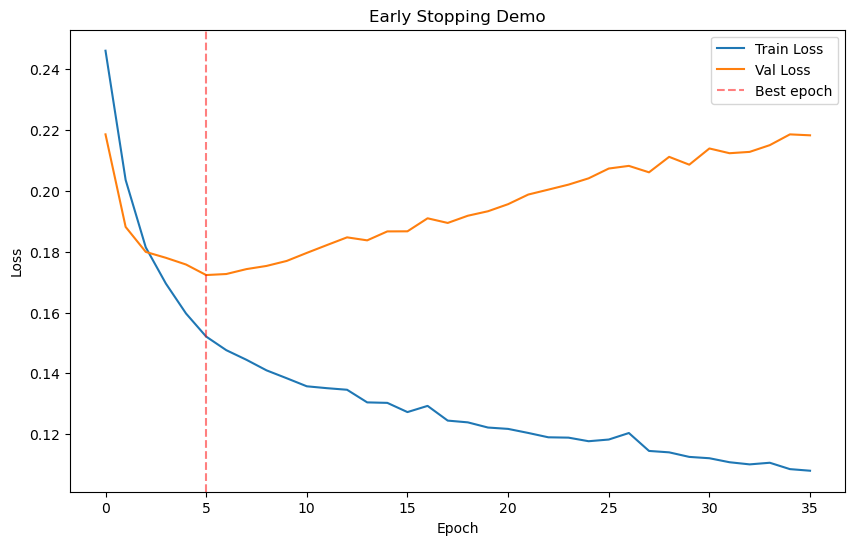

In [206]:
class EarlyStopping:
    def __init__(self, patience=30, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                return True
        return False

# Train with early stopping
mlp_es = MLPClassifier(hidden_sizes=[64, 64], learning_rate=0.1, n_epochs=1000,
                        batch_size=16, activation='relu', seed=42)
n, d = X_of_tr_s.shape
mlp_es._init_params(d, 1)
y2d = y_of_tr.reshape(-1, 1)
train_losses, val_losses = [], []
es = EarlyStopping(patience=30)

for epoch in range(1000):
    perm = mlp_es.rng.permutation(n)
    Xs, ys = X_of_tr_s[perm], y2d[perm]
    for start in range(0, n, 16):
        Xb = Xs[start:start+16]; yb = ys[start:start+16]; m = len(yb)
        acts, zs, masks = mlp_es._forward(Xb, training=True)
        deltas = [None] * len(mlp_es.weights)
        deltas[-1] = (acts[-1] - yb) / m
        for i in range(len(mlp_es.weights)-2, -1, -1):
            dd = deltas[i+1] @ mlp_es.weights[i+1].T * mlp_es._act_deriv(zs[i], False)
            if masks[i] is not None: dd = dd * masks[i]
            deltas[i] = dd
        for i in range(len(mlp_es.weights)):
            mlp_es.weights[i] -= mlp_es.lr * (acts[i].T @ deltas[i])
            mlp_es.biases[i] -= mlp_es.lr * np.sum(deltas[i], axis=0, keepdims=True)
    tp = mlp_es.predict_proba(X_of_tr_s)
    vp = mlp_es.predict_proba(X_of_te_s)
    eps = 1e-12
    tl = -np.mean(y_of_tr*np.log(tp+eps) + (1-y_of_tr)*np.log(1-tp+eps))
    vl = -np.mean(y_of_te*np.log(vp+eps) + (1-y_of_te)*np.log(1-vp+eps))
    train_losses.append(tl); val_losses.append(vl)
    if es(vl):
        print(f'Early stopping at epoch {epoch} (best val_loss={es.best_loss:.4f})')
        break

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Val Loss')
ax.axvline(epoch - es.counter, color='r', linestyle='--', alpha=0.5, label='Best epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Early Stopping Demo'); ax.legend()
plt.show()

---

## Summary

Congratulations! You've implemented from scratch:

| Method | Key Concepts Learned |
|---|---|
| **Linear Regression** | Normal equation, SSE, gradient descent, learning rate, SGD |
| **Logistic Regression** | Sigmoid, cross-entropy, decision boundary, softmax |
| **Perceptron** | Linear separability, weight update rule |
| **Generalization** | Overfitting, underfitting, bias-variance tradeoff |
| **Regularization** | L2 (Ridge), L1 (Lasso), cross-validation, dropout, early stopping |
| **MLP** | Forward prop, backprop, activation functions, He init, mini-batch GD |
| **Decision Trees** | Gini, entropy, information gain, recursive splitting, pruning |
| **Ensembles** | Bagging, random forest, AdaBoost, gradient boosting |

**Only NumPy and Matplotlib were used — no sklearn, no PyTorch!**